In [1]:
%matplotlib widget
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float64", dim=Any) # precision: float16|half|float32|single|float64|double
# dim: int or "Any"

import sphWarpCore as sph
from sphWarpCore.type_config import *

print(get_type_config()) # confirms active settings

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

# from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm
from compressibleSPH.enumTypes import *

{'scalar_t': <class 'warp._src.types.float64'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 100
band = 10
gamma = 3
leftState = sodInitialState(1, 1, 0)
# rightState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 4
smoothIC = True
timeLimit = 0.15

from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme

L = 2
dim = 1
# n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

config, integrator = buildConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx
# config.dx = L / (nx * 2)

# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('MonaghanCompressibleSPH')
# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('compSPH')
SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('crkSPH')

schemeConfig = SimulationConfig()
schemeConfig.gamma = gamma
schemeConfig.rho0 = leftState.rho
# schemeConfig.viscositySwitchParams.limitXi = True
schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False
# schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins
# schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Monaghan
# schemeConfig.adaptiveSupportCorrections = True

# schemeConfig.diffusionParams.C_l = 0.0
# schemeConfig.diffusionParams.C_q = 0.0


In [3]:

r_inner = 0.9
r_outer = 1.0
# dx = (r_outer - r_inner) / (nx + 1)
# print(dx)


domain = buildDomainDescription(r_outer * 1.1, 1, periodic = True, device = device, dtype = dtype)
dim = 1


# particles_l = sampleRegularParticles(nx + 20, buildDomainDescription(r_outer - r_inner + dx * 20, dim, periodic = False, device = device, dtype = dtype), targetNeighbors, jitter = 0.0)
print(nx)
particles_l = sampleRegularParticles(nx, buildDomainDescription(r_outer - r_inner, dim, periodic = True, device = device, dtype = dtype), config.targetNeighbors, jitter = 0.0)

normalized_positions = (particles_l.positions - particles_l.positions.min()) / (particles_l.positions.max() - particles_l.positions.min())

offset_positions = normalized_positions * (r_outer - r_inner) + r_inner

particles_l = particles_l._replace(positions = offset_positions)


dx = (particles_l.positions[1] - particles_l.positions[0]).cpu().numpy()

print(particles_l.positions[1] - particles_l.positions[0])
print(particles_l.positions.shape)
print(particles_l.positions.min(), particles_l.positions.max())

100
tensor([0.0010], device='cuda:0', dtype=torch.float64)
torch.Size([100, 1])
tensor(0.9000, device='cuda:0', dtype=torch.float64) tensor(1., device='cuda:0', dtype=torch.float64)


In [4]:
nu = dim
gamma = 1 + 2 / nu
schemeConfig.gamma = gamma


P_inner = 0.1
P_outer = 1.0

rho_outer = 0.01
rho_inner = (P_inner / P_outer)** (1/gamma) * rho_outer # Note that the paper disagrees with this and uses outer/inner. SPHERAL uses the flipped version
s = P_outer / rho_outer**gamma # paper uses inner/inner but these are equivalent here as the case is isentropic

print(f'r_inner = {r_inner}, r_outer = {r_outer}')
print(f'P_inner = {P_inner}, P_outer = {P_outer}')
print(f'rho_inner = {rho_inner}, rho_outer = {rho_outer}')
print(f's = {s}')

r_inner = 0.9, r_outer = 1.0
P_inner = 0.1, P_outer = 1.0
rho_inner = 0.004641588833612779, rho_outer = 0.01
s = 999999.9999999999


In [5]:
from compressibleSPH.caseUtils.kidder.kidder import KidderIsentropicCapsuleAnalyticSolution
kidderSolution = KidderIsentropicCapsuleAnalyticSolution(
    nu = nu,
    r0 = r_inner,
    r1 = r_outer,
    P0 = P_inner,
    P1 = P_outer,
    rho1 = rho_outer,
)

particles_l = particles_l._replace(
    densities = torch.tensor(kidderSolution.rho(0, torch.linalg.norm(particles_l.positions, dim = -1).cpu().numpy()), dtype = dtype, device = device),
    masses = torch.tensor(kidderSolution.rho(0, torch.linalg.norm(particles_l.positions, dim = -1).cpu().numpy()) * dx, dtype = dtype, device = device),
)

In [6]:
import numpy as np
t = 0
rInner = kidderSolution.rInner(t)
rOuter = kidderSolution.rOuter(t)

x = np.linspace(rInner, rOuter, 1000)
rho = kidderSolution.rho(t, x)
P = kidderSolution.P(t, x)
v = kidderSolution.vr(t, x)

pInner = kidderSolution.Pinner(t)
pOuter = kidderSolution.Pouter(t)

vInner = kidderSolution.vrInner(t)
vOuter = kidderSolution.vrOuter(t)

In [7]:
def kidderVelocity(t_, x):
    t = t_.cpu().numpy() if torch.is_tensor(t_) else t_
    r = torch.linalg.norm(x, dim = -1)
    # P = particles.pressures.cpu().numpy()
    # P = kidderSolution.P(t, r.cpu().numpy())
    Panalytic = kidderSolution.P(t, r.cpu().numpy())
    rhoAnalytic = kidderSolution.rho(t, r.cpu().numpy())

    uAnalytic = 1 / (schemeConfig.gamma - 1) * Panalytic / rhoAnalytic
    v = kidderSolution.vr(t, r.cpu().numpy())
    # print('Applying velocity, v = ', v, 't = ', t)
    return torch.tensor(v, dtype = x.dtype, device = x.device).view(-1,1)
def kidderDensity(t_, x):
    t = t_.cpu().numpy() if torch.is_tensor(t_) else t_
    r = torch.linalg.norm(x, dim = -1)
    # P = particles.pressures.cpu().numpy()
    # P = kidderSolution.P(t, r.cpu().numpy())
    Panalytic = kidderSolution.P(t, r.cpu().numpy())
    rhoAnalytic = kidderSolution.rho(t, r.cpu().numpy())

    uAnalytic = 1 / (schemeConfig.gamma - 1) * Panalytic / rhoAnalytic
    # print('Applying density')
    return torch.tensor(rhoAnalytic, dtype = x.dtype, device = x.device)
def kidderInternalEnergy(t_, x):
    t = t_.cpu().numpy() if torch.is_tensor(t_) else t_
    r = torch.linalg.norm(x, dim = -1)
    # P = particles.pressures.cpu().numpy()
    # P = kidderSolution.P(t, r.cpu().numpy())
    Panalytic = kidderSolution.P(t, r.cpu().numpy())
    rhoAnalytic = kidderSolution.rho(t, r.cpu().numpy())

    uAnalytic = 1 / (schemeConfig.gamma - 1) * Panalytic / rhoAnalytic
    # print('Applying internal energy')
    return torch.tensor(uAnalytic, dtype = x.dtype, device = x.device)
    
def kidderAcceleration(t_, x):
    t = t_.cpu().numpy() if torch.is_tensor(t_) else t_
    r = torch.linalg.norm(x, dim = -1)
    # P = particles.pressures.cpu().numpy()
    # P = kidderSolution.P(t, r.cpu().numpy())
    Panalytic = kidderSolution.P(t, r.cpu().numpy())
    rhoAnalytic = kidderSolution.rho(t, r.cpu().numpy())

    uAnalytic = 1 / (schemeConfig.gamma - 1) * Panalytic / rhoAnalytic
    v = kidderSolution.accelr(t, r.cpu().numpy())
    # print('Applying velocity, v = ', v, 't = ', t)
    return torch.tensor(v, dtype = x.dtype, device = x.device).view(-1,1)

In [8]:
from compressibleSPH.boundaryConditions import *

def buffer_sdf(position):
    dist = torch.ones_like(position[:,0])
    dist[:band] = -1
    dist[-band:] = -1
    # dist[:] = -1
    return dist
def buffer_sdf_gradient(position):
    dist = torch.ones_like(position[:,0])
    dist[:band] = 1
    dist[-band:] = -1
    return dist


kidderBC = BoundaryCondition(
    type = BoundaryConditionType.dynamic,
    sdf = lambda x: (buffer_sdf(x), buffer_sdf_gradient(x)),
    dirichletFunctions = {
        'velocities': lambda state, cfg, schemeCfg, positions, d, n, t, dt: kidderVelocity(t, positions),
        'densities': lambda state, cfg, schemeCfg, positions, d, n, t, dt: kidderDensity(t, positions),
        'internalEnergies': lambda state, cfg, schemeCfg, positions, d, n, t, dt: kidderInternalEnergy(t, positions),
    },
    updateFunctions = {
        # 'dvdt': lambda state, cfg, schemeCfg, positions, d, n, t, dt: kidderAcceleration(t, positions),
        'dxdt': lambda state, cfg, schemeCfg, positions, d, n, t, dt: kidderVelocity(t, positions),
    }
)
schemeConfig.boundaryConditions.clear()
schemeConfig.boundaryConditions.append(kidderBC)

In [9]:
from compressibleSPH.modules import *


Pinitial = torch.tensor(kidderSolution.P(t, torch.linalg.norm(particles_l.positions, dim = -1).cpu().numpy()), dtype = dtype, device = device)
# Pinitial[:10] = pInner
# Pinitial[-10:] = pOuter
print(Pinitial.shape)

dx = (particles_l.positions[1] - particles_l.positions[0]).cpu().numpy()
dx = (r_outer - r_inner) / (nx-1)

particles_l = particles_l._replace(
    densities = torch.tensor(kidderSolution.rho(0, torch.linalg.norm(particles_l.positions, dim = -1).cpu().numpy()), dtype = dtype, device = device),
    masses = torch.tensor(kidderSolution.rho(0, torch.linalg.norm(particles_l.positions, dim = -1).cpu().numpy()) * dx, dtype = dtype, device = device),
)

simulationState = SimulationState(
    positions = particles_l.positions,
    supports = particles_l.supports,
    masses = particles_l.masses,
    densities = particles_l.densities,        
    velocities = torch.zeros_like(particles_l.positions),

    kinds = torch.zeros_like(particles_l.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_l.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_l.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter= particles_l.positions.shape[0],
    
    internalEnergies = None,
    totalEnergies = None,
    entropies = None,
    pressures = None,
    soundspeeds = None,

    alphas = torch.ones_like(particles_l.densities),
    alpha0s = torch.ones_like(particles_l.densities),
    divergence = torch.zeros_like(particles_l.densities)
)

densities = warpOperation(
    simulationState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather,
    ),
    domain = config.domain,
    adjacency=None
)
# simulationState.densities[band:-band] = densities[band:-band]

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = simulationState.densities, gamma = schemeConfig.gamma)
v_initial = torch.zeros_like(particles_l.positions)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(v_initial, dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles_l.masses



simulationState.internalEnergies = u_
simulationState.pressures = P_
simulationState.soundspeeds = c_s
simulationState.entropies = A_
simulationState.totalEnergies = u_ + torch.linalg.norm(v_initial, dim = -1)**2/2 

simulationState.velocities = v_initial

kineticEnergy = 0.5 * (torch.linalg.norm(simulationState.velocities, dim = -1) **2 * simulationState.masses).sum()
thermalEnergy = (simulationState.internalEnergies * simulationState.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

kineticEnergy = 0.5 * (torch.linalg.norm(simulationState.velocities, dim = -1) **2 * simulationState.masses).sum()
thermalEnergy = (simulationState.internalEnergies * simulationState.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

err = kidderInternalEnergy(0, particles_l.positions).flatten() - u_
print('Initial total energy: ', totalEnergy.sum().item())
print('Initial kinetic energy: ', kineticEnergy.sum().item())
print('Initial thermal energy: ', thermalEnergy.sum().item())
print('Max internal energy error: ', err.abs().max().item())

err_rho = kidderSolution.rho(0, particles_l.positions.cpu().numpy()).flatten() - simulationState.densities.cpu().numpy()
print('Max density error: ', np.abs(err_rho).max().item())
err_pressure = kidderSolution.P(0, particles_l.positions.cpu().numpy()).flatten() - simulationState.pressures.cpu().numpy()
print('Max pressure error: ', np.abs(err_pressure).max().item())

sampled_rho = densities.cpu().numpy()[band:-band]
sampled_solution_rho = kidderSolution.rho(0, simulationState.positions.cpu().numpy())[band:-band].flatten()
print('Max sampled density error: ', np.abs(sampled_solution_rho - sampled_rho).max().item())

# print(f'Current Density: {simulationState.densities}')
# print(f'Target Density: {kidderSolution.rho(0, simulationState.positions.cpu().numpy()).flatten()}')

# print(f'Current Pressure: {simulationState.pressures}')
# print(f'Target Pressure: {kidderSolution.P(0, simulationState.positions.cpu().numpy()).flatten()}')

# print(f'Current Internal Energy: {simulationState.internalEnergies}')
# print(f'Target Internal Energy: {kidderInternalEnergy(0, simulationState.positions).flatten()}')

# print(f'Initial total energy: {totalEnergy:.3g}, kinetic energy: {kineticEnergy:.3g}, thermal energy: {thermalEnergy:.3g}')

# rho = warpOperation(
#     simulationState,
#     OperationProperties(
#         kernel = config.kernel,
#         operation = WarpOperation.Density,
#         supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
#     ),
#     domain = config.domain,
#     adjacency = None,
# )

# print('Initial density: ', rho)


torch.Size([100])
Module sphWarpCore.radiusSearch.wp_compactHash 0833861 load on device 'cuda:0' took 4.82 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 15e019a load on device 'cuda:0' took 8.04 ms  (cached)
Initial total energy:  0.02482446955338605
Initial kinetic energy:  0.0
Initial thermal energy:  0.02482446955338605
Max internal energy error:  0.0
Max density error:  0.0
Max pressure error:  0.0
Max sampled density error:  2.745672319547435e-07


[2.74567232e-07 2.64149785e-07 2.54364428e-07 2.45158872e-07
 2.36486258e-07 2.28304482e-07 2.20575619e-07 2.13265429e-07
 2.06342925e-07 1.99780006e-07 1.93551134e-07 1.87633055e-07
 1.82004554e-07 1.76646240e-07 1.71540358e-07 1.66670625e-07
 1.62022083e-07 1.57580968e-07 1.53334596e-07 1.49271264e-07
 1.45380156e-07 1.41651263e-07 1.38075311e-07 1.34643696e-07
 1.31348426e-07 1.28182068e-07 1.25137700e-07 1.22208873e-07
 1.19389566e-07 1.16674157e-07 1.14057389e-07 1.11534340e-07
 1.09100402e-07 1.06751251e-07 1.04482829e-07 1.02291326e-07
 1.00173157e-07 9.81249498e-08 9.61435298e-08 9.42259035e-08
 9.23692480e-08 9.05708985e-08 8.88283381e-08 8.71391874e-08
 8.55011959e-08 8.39122330e-08 8.23702808e-08 8.08734271e-08
 7.94198581e-08 7.80078521e-08 7.66357757e-08 7.53020749e-08
 7.40052737e-08 7.27439680e-08 7.15168216e-08 7.03225619e-08
 6.91599767e-08 6.80279103e-08 6.69252607e-08 6.58509764e-08
 6.48040537e-08 6.37835338e-08 6.27885006e-08 6.18180784e-08
 6.08714302e-08 5.994775

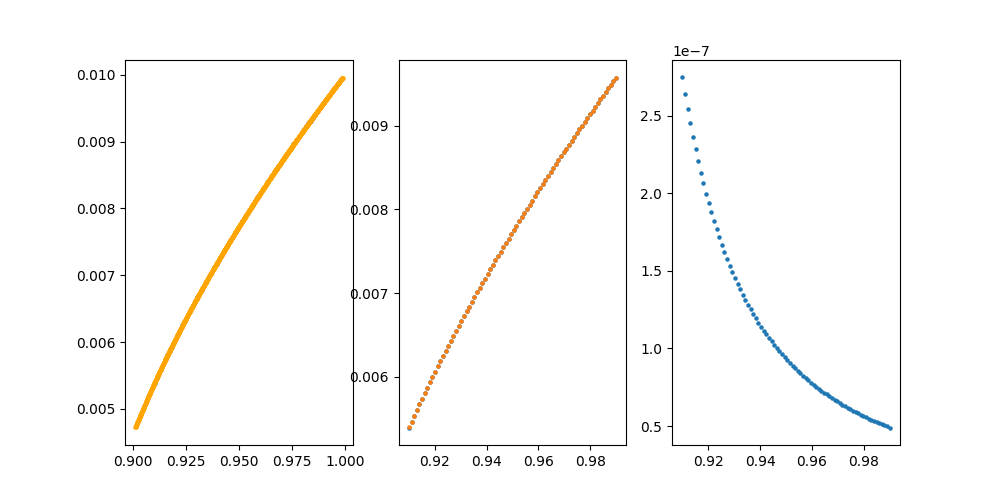

In [10]:
fig, axis = plt.subplots(1, 3, figsize = (10, 5), squeeze=False)
axis[0,0].scatter(simulationState.positions.cpu()[band:-band], densities.cpu()[band:-band], label = 'SPH Density', s = 5)
axis[0,0].scatter(x[band:-band], rho[band:-band], label = 'Analytic Density', color = 'orange', s = 5)

axis[0,1].scatter(simulationState.positions.cpu()[band:-band], sampled_rho, label = 'Sampled Density', s = 5)
axis[0,1].scatter(simulationState.positions.cpu()[band:-band], sampled_solution_rho, label = 'Solution Density', s = 5)

diff = np.abs(sampled_solution_rho.flatten() - sampled_rho)
print(diff)
axis[0,2].scatter(simulationState.positions.cpu()[band:-band], diff, label = 'Density Error', s = 5)

In [11]:
print(f'Density Min: {simulationState.densities.min().item()}, Density Max: {simulationState.densities.max().item()}')
print(f'Pressure Min: {simulationState.pressures.min().item()}, Pressure Max: {simulationState.pressures.max().item()}')
print(f'Internal Energy Min: {simulationState.internalEnergies.min().item()}, Internal Energy Max: {simulationState.internalEnergies.max().item()}')

Density Min: 0.004641588833612779, Density Max: 0.01
Pressure Min: 0.09999999999999999, Pressure Max: 1.0
Internal Energy Min: 10.772173450159418, Internal Energy Max: 50.0


In [12]:
from compressibleSPH.modules.timestep.compressible import computeTimestep

compressibleSystem = SimulationSystem(
    state=simulationState, 
    adjacency = None, 
    domain = config.domain)

# dx = simulationState.positions[1] - simulationState.positions[0]
config.dx = dx
config.dt = computeTimestep(compressibleSystem, config, schemeConfig, dt = config.dt)
# config.dt = 1e-4
print(f"Initial timestep: {config.dt}")


timeLimit = 0.99 * kidderSolution.tau
# dt = computeDT(particleSystem.systemState, 0.05, solverConfig) / 10
timesteps = int(timeLimit / config.dt)
# simulationState = copy.deepcopy(particleSystem)
print(f"Running with dt: {config.dt}, which gives nSteps: {timesteps}")

Initial timestep: 1.7922448093701842e-05
Running with dt: 1.7922448093701842e-05, which gives nSteps: 1569


In [13]:
# runningSystem = compressibleSystem.initializeNewState()
runningState = compressibleSystem.initializeNewState()

In [14]:

# from sphWarpCore import *
# from compressibleSPH.systems.compSPH import CompSPHSystem, CompSPHState
# from compressibleSPH.configurations.compSPHConfig import CompSPHConfig
# from compressibleSPH.configurations.simulationConfig import SimulationConfig
# from compressibleSPH.systems.compressibleMonaghan import CompressibleSystemUpdate

# def enforceDirichlet(
#     system: CompSPHSystem,
#     dt: float,
#     config: SimulationConfig,
#     compParams: CompSPHConfig,
# ):
#     for bc in compParams.boundaryConditions:
#         if bc.dirichletFunctions is not None and len(bc.dirichletFunctions) > 0:
#             for varName, dirichletFn in bc.dirichletFunctions.items():
#                 print(f'Enforcing dirichlet for {varName}')
#                 var = getattr(system.state, varName)
#                 d, n = bc.sdf(system.state.positions)
#                 updatedValues = dirichletFn(system.state, config, compParams, system.state.positions, d, n, system.t, dt)
#                 var[d < 0] = updatedValues[d < 0]
#                 # print(f'Enforced dirichlet for {varName}')
                
# def computeForcing(
#     system: CompSPHSystem,
#     dt: float,
#     config: SimulationConfig,
#     compParams: CompSPHConfig,
# ):
#     totalForcing = torch.zeros_like(system.state.positions)
#     for bc in compParams.boundaryConditions:
#         if bc.forcingFunctions is not None and len(bc.forcingFunctions) > 0:
#             for forcingFn in bc.forcingFunctions:
#                 d, n = bc.sdf(system.state.positions)
#                 forcingValues = forcingFn(system.state, config, compParams, system.state.positions, d, n, system.t, dt)
#                 totalForcing[d < 0] += forcingValues[d < 0]
#     return totalForcing

# def enforceUpdates(
#     updates: CompressibleSystemUpdate,
#     system: CompSPHSystem,
#     dt: float,
#     config: SimulationConfig,
#     compParams: CompSPHConfig,
# ):
#     for bc in compParams.boundaryConditions:
#         if bc.updateFunctions is not None and len(bc.updateFunctions) > 0:
#             for varName, updateFn in bc.updateFunctions.items():
#                 # print(f'Enforcing updates for {varName}')
#                 var = getattr(updates, varName)
#                 d, n = bc.sdf(system.state.positions)
#                 updatedValues = updateFn(system.state, config, compParams, system.state.positions, d, n, system.t, dt)
#                 var[d < 0] = updatedValues[d < 0]
#                 # print(f'Enforced updates for {varName}')

In [15]:

# from compressibleSPH.modules.adaptiveSupport import computeOmega
# from compressibleSPH.modules.compSPH.accel import computeCompSPHAccelWarp
# from compressibleSPH.modules.compSPH.dudt import computeCompSPHdudtWarp
# from compressibleSPH.modules.compSPH.balance import computeCompSPHBalanceTermWarp
# from compressibleSPH.enumTypes import EnergyScheme
# from compressibleSPH.modules import *

# from sphWarpCore import *
# from compressibleSPH.systems.compSPH import CompSPHSystem, CompSPHState
# from compressibleSPH.configurations.compSPHConfig import CompSPHConfig
# from compressibleSPH.configurations.simulationConfig import SimulationConfig
# import torch
# from compressibleSPH.systems.compressibleMonaghan import CompressibleSystemUpdate
# # from diffSPH.schemes.states.compressiblesph import CompressibleState as CompState
# # from diffSPH.kernels import getSPHKernelv2
# # from diffSPH.neighborhood import evaluateNeighborhood
# # from diffSPH.enums import KernelType as KernelTypeDiffSPH

# # from diffSPH.modules.compSPH import compSPH_acceleration, compSPH_dudt, compute_fij
# # from diffSPH.enums import EnergyScheme as EnergySchemeDiffSPH

# from compressibleSPH.modules.shockCapturing.CullenHopkins import computeHopkinsTerms, computeHopkinsUpdate

# def compSPH_step(
#     system: CompSPHSystem,
#     dt: float,
#     config: SimulationConfig,
#     compParams: CompSPHConfig,
#     verbose = False,
# ):

#     currentSystem = system#
#     currentState = currentSystem.state

#     rho_optimal, h_optimal, currentSystem.adjacency, *_ = evaluateOptimalSupport(currentState, config, compParams, SupportScheme.Gather, currentSystem.adjacency)
#     currentState.supports = h_optimal
#     currentState.densities = rho_optimal

#     verletScale = config.verletScale

#     adjacency = buildVerletList(
#         currentState, 
#         config.domain, verletScale = verletScale, supportMode = SupportScheme.SuperSymmetric,
#         priorNeighborhood = currentSystem.adjacency,
#         verbose = False)

#     currentState.densities = warpOperation(
#         currentState,
#         OperationProperties(
#             kernel = config.kernel,
#             operation = WarpOperation.Density,
#             supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
#         ),
#         domain = config.domain,
#         adjacency = adjacency,
#     )
#     if currentState.divergence is None:
#         print('Warning: divergence is None, computing for the first time')
#         drhodt = computeMomentumConsistent(
#             currentState,
#             config,
#             supportScheme = SupportScheme.Gather, 
#             adjacency = adjacency,
#             gradH = gradHState
#         )
#         currentState.divergence = drhodt

#     enforceDirichlet(currentSystem, dt, config, compParams)

#     currentState.entropies, _, currentState.pressures, currentState.soundspeeds = idealGasEOS(
#         A = None,
#         u = currentState.internalEnergies,
#         P = None,
#         rho = currentState.densities,
#         gamma = compParams.gamma,
#     )

#     if compParams.adaptiveSupportCorrections:
#         omega = computeOmega(currentState, 
#                 OperationProperties(
#                     kernel = config.kernel,
#                     supportMode = SupportScheme.Gather, # E.5
#                 ),
#                 domain = config.domain,
#                 adjacency = adjacency
#         )

#         gradHState = GradHState(
#             queryOmegas = omega
#         )
#     else:
#         gradHState = None

#     currentState.alphas, switchState = computeViscositySwitchTerms(
#         dt,
#         currentState, 
#         config, compParams, 
#         SupportScheme.SuperSymmetric, 
#         adjacency)   


#     dvdt, currentState.ap_ij, currentState.av_ij = computeCompSPHAccelWarp(
#         queryParticles = currentState,
#         operationProperties = OperationProperties(
#             kernel = config.kernel,
#             supportMode =  SupportScheme.KernelMeanSymmetric
#         ),
#         domain = config.domain,
#         conductivityParams= compParams.diffusionParams,

#         queryEnergies = currentState.internalEnergies,
#         queryVelocities= currentState.velocities,
#         queryCs = currentState.soundspeeds,
#         queryAlphas = currentState.alphas,
#         queryPressures = currentState.pressures,

#         adjacency = adjacency,
#         gradHState = gradHState
#     )

#     dudt = computeCompSPHdudtWarp(
#         queryParticles = currentState,
#         operationProperties = OperationProperties(
#             kernel = config.kernel,
#             supportMode = SupportScheme.Gather #E.3
#          ),
#         domain = config.domain,
#         conductivityParams= compParams.diffusionParams,

#         queryEnergies = currentState.internalEnergies,
#         queryVelocities= currentState.velocities,
#         queryCs = currentState.soundspeeds,
#         queryAlphas = currentState.alphas,
#         queryPressures = currentState.pressures,

#         adjacency = adjacency,
#         gradHState = gradHState
#     )

#     v_halfstep = currentState.velocities + 0.5 * dt * dvdt

#     currentState.f_ij = computeCompSPHBalanceTermWarp(
#         queryParticles = currentState,
#         operationProperties = OperationProperties(
#             kernel = config.kernel,
#             supportMode = config.supportMode
#         ),
#         domain = config.domain,

#         queryEnergies = currentState.internalEnergies,
#         queryVelocities= v_halfstep,
#         queryPressures = currentState.pressures,

#         pairWise_pressureAccel= currentState.ap_ij,
#         pairWise_viscosityAccel = currentState.av_ij,
#         energyScheme = compParams.energyScheme,
#         dt= dt.detach().cpu().item() if isinstance(dt, torch.Tensor) else dt,
#         gamma = compParams.gamma,

#         adjacency = adjacency,
#         gradHState = gradHState
#     )
#     # particles.alpha0s, switchState = updateViscositySwitch(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, config, dt, dvdt, switchState)

#     currentState.alpha0s, switchState = updateViscositySwitch(
#         switchState,
#         dt, dvdt,
#         currentState, 
#         config, compParams, 
#         SupportScheme.SuperSymmetric, 
#         adjacency)   


#     drhodt = computeMomentumConsistent(
#         currentState,
#         config,
#         supportScheme = SupportScheme.Gather,
#         adjacency = adjacency,
#         gradH = gradHState
#     )
#     currentState.divergence = -drhodt / currentState.densities
#     dEdt = currentState.masses * torch.einsum('ij,ij->i', currentState.velocities, (dvdt)) + currentState.masses * (dudt)

#     forcing = computeForcing(currentSystem, dt, config, compParams)
#     dvdt += forcing / currentState.masses.view(-1,1)

#     update = CompressibleSystemUpdate(
#         dxdt = currentState.velocities.clone(),
#         dvdt = dvdt,
#         dudt = dudt,
#         drhodt = drhodt,
#         dEdt = dEdt,
#     )

#     enforceUpdates(update, currentSystem, dt, config, compParams)

#     return update, adjacency, currentState



In [16]:
# compSPH_step(
#     runningState,
#     config.dt,
#     config,
#     schemeConfig,
# )

In [17]:
def interval_sdf(position, intervalBegin, intervalEnd):
    distToBegin = position - intervalBegin
    distToEnd = position - intervalEnd
    
    distToClosest = torch.where(
        torch.abs(distToBegin) < torch.abs(distToEnd),
        -distToBegin,
        distToEnd
    )
    return distToClosest[:,0]
def interval_sdf_gradient(position, intervalBegin, intervalEnd):
    distToBegin = position - intervalBegin
    distToEnd = position - intervalEnd
    distToClosest = torch.where(
        torch.abs(distToBegin) < torch.abs(distToEnd),
        distToBegin,
        distToEnd
    )
    
    direction = -torch.where(distToClosest == distToBegin, torch.sign(distToBegin), torch.sign(distToEnd))
    return direction

def buffer_sdf(position):
    dist = torch.ones_like(position[:,0])
    dist[:10] = -1
    dist[-10:] = -1
    # dist[:] = -1
    return dist
def buffer_sdf_gradient(position):
    dist = torch.ones_like(position[:,0])
    dist[:10] = 1
    dist[-10:] = -1
    return dist


domain_sdf = lambda x:( interval_sdf(x, -2, 2), interval_sdf_gradient(x, -2, 2) )
domain_sdf = lambda x: (buffer_sdf(x), buffer_sdf_gradient(x))
dt = 1e-1


from diffSPH.kernels import KernelType
from diffSPH.simple import buildRegion

solverConfig = {    
    'diffusion':{
        'C_l': 1,
        'C_q': 1,
        'Cu_l': 1,
        'Cu_q': 1,
        'monaghanSwitch': True,
        'viscosityTerm': 'Monaghan',
        'correctXi': True,
        
        'viscosityFormulation': 'Monaghan1992',
        'thermalConductivityFormulation': 'Price2008',
        'signalTerm': 'Price2019',
        'use_cbar': False,
        'use_rho_bar': False,
        'use_h_bar': False,
        'scaleBeta': False,
        'K': 1.0,
        
        'thermalConductivity' : 0.0,
    },

    'particle':{
        'nx': nx,
        'dx': dx,
    'targetNeighbors': config.targetNeighbors,
    },
    'diffusionSwitch':{
        'scheme': ViscositySwitch.NoneSwitch,
        'limitXi': False,
    },
    'domain': config.domain,
    'kernel': KernelType.B7,
    'verbose': True,
    'gamma': schemeConfig.gamma,
    'fluid':{
        'gamma': schemeConfig.gamma,
    },
    'support':{
        'iterations': 1,
        'LUT': None
    },
}

regions = []
regions.append(buildRegion(
    sdf = domain_sdf,
    config = solverConfig,
    type = 'dirichlet',
    dirichletValues={
        'velocities': lambda x, mask, state, t, dt: kidderVelocity(t, x),
        'densities': lambda x, mask, state, t, dt: kidderDensity(t, x),
        'internalEnergies': lambda x, mask, state, t, dt: kidderInternalEnergy(t, x),
    },
    updateValues={
        # 'dvdt': lambda x, mask, state, t, dt: kidderAcceleration(t , x),
        'dxdt': lambda x, mask, state, t, dt: kidderVelocity(t , x)
    }
))
solverConfig['regions'] = regions

0.0


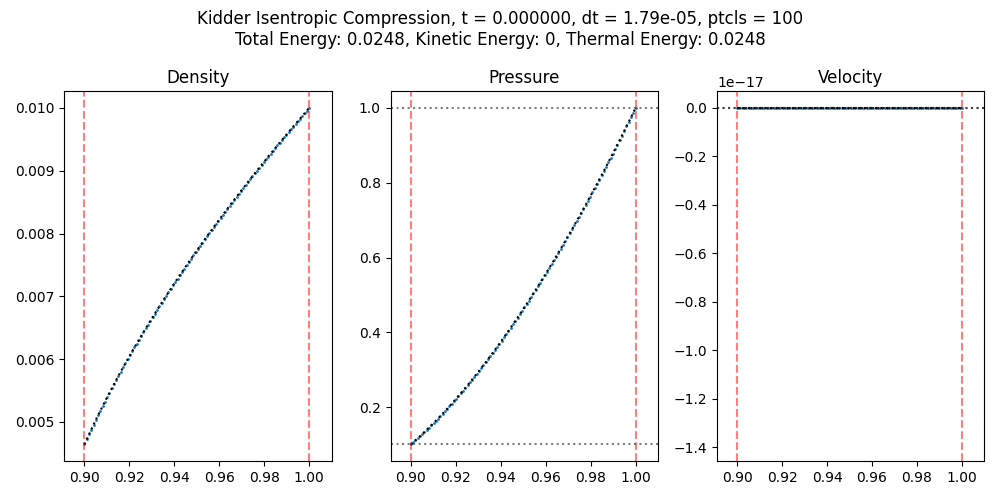

In [18]:
fig, axis = plt.subplots(1, 3, figsize = (10, 5), squeeze=False)

def setupPlot(fig, axis, t):
    # print(t)
    rInner = kidderSolution.rInner(t)
    rOuter = kidderSolution.rOuter(t)

    x = np.linspace(rInner, rOuter, 1000)
    rho = kidderSolution.rho(t, x)
    P = kidderSolution.P(t, x)
    # v = kidderSolution.vr(t+660*dt.cpu().item(), x)
    v = kidderSolution.vr(t, x)

    pInner = kidderSolution.Pinner(t)
    pOuter = kidderSolution.Pouter(t)

    vInner = kidderSolution.vrInner(t)
    vOuter = kidderSolution.vrOuter(t)

    axis[0,0].plot(x, rho, 'black', ls = ':', label = 'Analytic')
    axis[0,1].axhline(pInner, color = 'black', ls = ':', alpha = 0.5)
    axis[0,1].axhline(pOuter, color = 'black', ls = ':', alpha = 0.5)
    axis[0,1].plot(x, P, 'black', ls = ':', label = 'Analytic')
    axis[0,2].plot(x, v, 'black', ls = ':', label = 'Analytic')
    axis[0,2].axhline(vInner, color = 'black', ls = ':', alpha = 0.5)
    axis[0,2].axhline(vOuter, color = 'black', ls = ':', alpha = 0.5)

    axis[0,0].set_title('Density')
    axis[0,1].set_title('Pressure')
    axis[0,2].set_title('Velocity')
    
    for ax in axis[0]:
        ax.axvline(rInner, color = 'r', ls = '--', alpha = 0.5)
        ax.axvline(rOuter, color = 'r', ls = '--', alpha = 0.5)
        ax.set_xlim(rInner * 0.99, rOuter * 1.01)
# setupPlot(fig, axis, 0)


# neighborhood, neighbors = evaluateNeighborhood(simulationState.systemState, domain, kernel, verletScale = solverConfig['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(simulationState.systemState, neighbors.neighbors, which = 'noghost')).rowEntries
# densities = computeDensity(simulationState.systemState, kernel, neighbors.get('noghost'), SupportScheme.Gather)


kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy
setupPlot(fig, axis, (runningState.t).item() if isinstance(runningState.t, torch.Tensor) else runningState.t)
axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = 1)
axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.pressures.cpu().numpy(), s = 1)
axis[0,2].scatter(runningState.state.positions.cpu().numpy(), runningState.state.velocities.cpu().numpy(), s = 1)
fig.suptitle(f'Kidder Isentropic Compression, t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
# fig.canvas.draw()
# fig.canvas.flush_events()
print(runningState.t)

fig.tight_layout()


In [19]:
# timesteps = 100
config.minDt = 1e-8
config.dt = computeTimestep(runningState, config, schemeConfig, dt = config.dt)
print(f"Initial timestep: {config.dt}")

# schemeConfig.crkViscosityParams.forceVanLeerOff = False
# schemeConfig.crkViscosityParams.forceVanLeerOn = True
# schemeConfig.crkViscosityParams.enableCRKLimiter = False

schemeConfig.crkViscosityParams.enableCRKLimiter = True
schemeConfig.crkViscosityParams.enableVanLeerLimiter = True

schemeConfig.diffusionParams.C_q = 1.0
schemeConfig.diffusionParams.C_l = 1.0


display(schemeConfig.crkViscosityParams)

Initial timestep: 1.7922448093701842e-05


CRKViscosity(
	eta_fold=float64(0),
	eta_crit=float64(0),
	enableCRKLimiter=True,
	enableVanLeerLimiter=True,
	forceVanLeerOff=bool(False),
	forceVanLeerOn=bool(False),
)

In [20]:
from compressibleSPH.schemes.compSPH import compSPH_step
# config.dt = 1e-4
# timeLimit = 1 / c_min
# t_limit = timeLimit
# config.dt = t_limit / 1000
# nSteps = int(t_limit / config.dt) 

# print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 20

runningState = compressibleSystem.initializeNewState()
config.dt = computeTimestep(runningState, config, schemeConfig, dt = config.dt)
print(f"Initial timestep after initialization: {config.dt}")

trajectory = []

priorStep = None
i = 0
t = 0
tq = tqdm(total = 1000, leave = True)

while t < timeLimit:
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = schemeConfig,
        verbose = False,
        # dsphConfig = solverConfig
        # priorStep = priorStep
    )
    t = result.state.t.item() if isinstance(result.state.t, torch.Tensor) else result.state.t
    tq.n = int(t / timeLimit * 1000)

    v = kidderSolution.vr(result.state.t.cpu().numpy() if isinstance(result.state.t, torch.Tensor) else result.state.t, result.state.state.positions.cpu().numpy()[:,0])
    
    result.state.state.velocities[:band,0] = torch.tensor(v[:band], dtype=result.state.state.velocities.dtype, device = result.state.state.velocities.device)
    result.state.state.velocities[-band:,0] = torch.tensor(v[-band:], dtype=result.state.state.velocities.dtype, device = result.state.state.velocities.device)
    # result.state.state.velocities[:,0] = torch.tensor(v, dtype=result.state.state.velocities.dtype, device = result.state.state.velocities.device)
    # result.state.state.internalEnergies = torch.tensor(kidderInternalEnergy(result.state.t, result.state.state.positions), dtype=result.state.state.internalEnergies.dtype, device = result.state.state.internalEnergies.device).flatten()

    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    # print(f"Step {i}: Time = {t:.4g}, Step Time = {timing:.3f} ms, vel nans: {torch.isnan(result.state.state.velocities).sum()}, infs: {torch.isinf(result.state.state.velocities).sum()}, pos nans: {torch.isnan(result.state.state.positions).sum()}, infs: {torch.isinf(result.state.state.positions).sum()}")

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )

    config.dt = computeTimestep(runningState, config, schemeConfig, dt = config.dt)
    # print(f"Computed new timestep: {config.dt}")

    i = i+1

    tq.set_description(f"{i:6d}: time: {t:8.4g}/{timeLimit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g}, step time: {timing:.3f}ms, adaptive dt: {config.dt:.3g}")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    # print(runningState.t)
    if i % 300 == 0 or i == timesteps - 1 or t >= timeLimit:
        axis[0,0].cla()
        axis[0,1].cla()
        axis[0,2].cla()

        setupPlot(fig, axis, runningState.t.item() if isinstance(runningState.t, torch.Tensor) else runningState.t)
        # plotState(fig, axis, runningState)
        # fig.tight_layout()
        axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = 1)
        axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.pressures.cpu().numpy(), s = 1)
        axis[0,2].scatter(runningState.state.positions.cpu().numpy(), runningState.state.velocities.cpu().numpy(), s = 1)
        fig.suptitle(f'Kidder Isentropic Compression, t = {runningState.t:2e}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')

        fig.canvas.draw()
        fig.canvas.flush_events()
        # break
        

Initial timestep after initialization: 1.7922448093701842e-05


  0%|          | 0/1000 [00:00<?, ?it/s]

Module compressibleSPH.modules.adaptiveSupport.wp_psi 4cacf24 load on device 'cuda:0' took 2.45 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_psi0 f9bb264 load on device 'cuda:0' took 6.58 ms  (cached)
Module sphWarpCore.operations.wp_density 813da29 load on device 'cuda:0' took 4.65 ms  (cached)
Module sphWarpCore.crk.crk_volume 45354f1 load on device 'cuda:0' took 2.82 ms  (cached)
Module sphWarpCore.crk.crk_moments 4bf48cf load on device 'cuda:0' took 4.13 ms  (cached)
Module sphWarpCore.crk.crk_density c687978 load on device 'cuda:0' took 1.85 ms  (cached)
Module sphWarpCore.operations.wp_gradient 0da391f load on device 'cuda:0' took 9.37 ms  (cached)
Module compressibleSPH.modules.crk.accel 519dcfe load on device 'cuda:0' took 9.50 ms  (cached)
Module compressibleSPH.modules.crk.dudt 7283a36 load on device 'cuda:0' took 4.03 ms  (cached)
Module compressibleSPH.modules.compSPH.balance faff88a load on device 'cuda:0' took 2.08 ms  (cached)


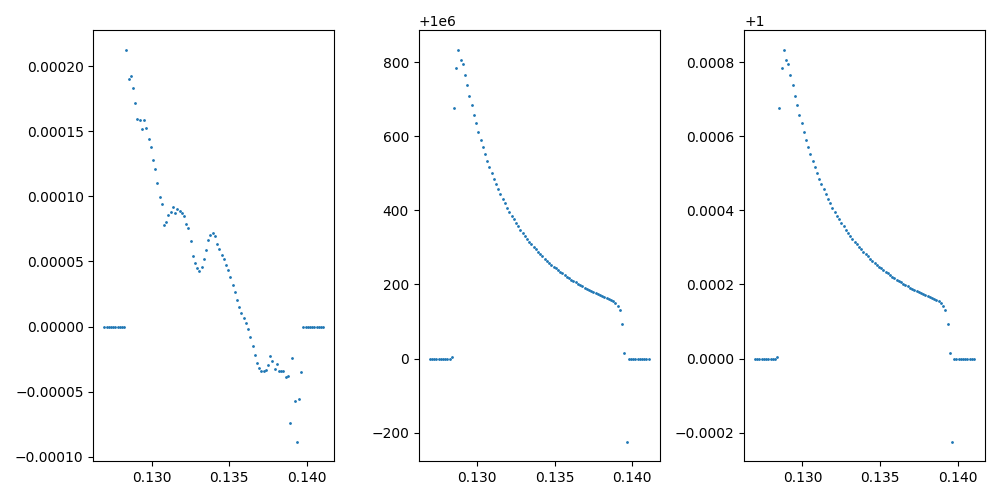

In [21]:
fig, axis = plt.subplots(1, 3, figsize = (10, 5), squeeze=False)
# setupPlot(fig, axis, 0)

vel_error = kidderSolution.vr(runningState.t.cpu().numpy() if isinstance(runningState.t, torch.Tensor) else runningState.t, runningState.state.positions.cpu().numpy()[:,0]) - runningState.state.velocities.cpu().numpy()[:,0]
axis[0,0].scatter(runningState.state.positions.cpu().numpy(), vel_error, s = 1)

# axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = 1)
# axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.supports.cpu().numpy(), s = 1)

entropy = runningState.state.entropies
# axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = 1)
axis[0,1].scatter(runningState.state.positions.cpu().numpy(), entropy.cpu().numpy(), s = 1)

entropySolution = kidderSolution.P(0, runningState.state.positions.cpu().numpy()) / kidderSolution.rho(0, runningState.state.positions.cpu().numpy())**schemeConfig.gamma
# axis[0,1].scatter(runningState.state.positions.cpu().numpy(), entropySolution, s = 1)

axis[0,2].scatter(runningState.state.positions.cpu().numpy(), entropy.cpu().numpy() / entropySolution.flatten(), s = 1)

fig.tight_layout()

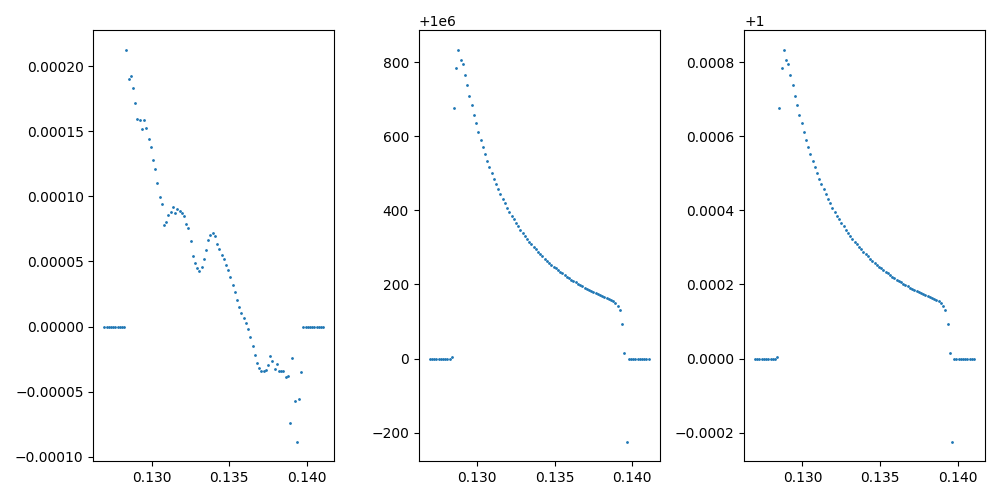

In [22]:
fig, axis = plt.subplots(1, 3, figsize = (10, 5), squeeze=False)
# setupPlot(fig, axis, 0)

vel_error = kidderSolution.vr(runningState.t.cpu().numpy() if isinstance(runningState.t, torch.Tensor) else runningState.t, runningState.state.positions.cpu().numpy()[:,0]) - runningState.state.velocities.cpu().numpy()[:,0]
axis[0,0].scatter(runningState.state.positions.cpu().numpy(), vel_error, s = 1)

# axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = 1)
# axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.supports.cpu().numpy(), s = 1)

entropy = runningState.state.entropies
# axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = 1)
axis[0,1].scatter(runningState.state.positions.cpu().numpy(), entropy.cpu().numpy(), s = 1)

entropySolution = kidderSolution.P(0, runningState.state.positions.cpu().numpy()) / kidderSolution.rho(0, runningState.state.positions.cpu().numpy())**schemeConfig.gamma
# axis[0,1].scatter(runningState.state.positions.cpu().numpy(), entropySolution, s = 1)

axis[0,2].scatter(runningState.state.positions.cpu().numpy(), entropy.cpu().numpy() / entropySolution.flatten(), s = 1)

fig.tight_layout()

In [24]:
cState = runningState.initializeNewState()
currentState = cState.state


adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, currentState.densities, crkState = computeCRKFactors(currentState, config.domain, config.kernel, adjacency = adjacency)


velocityGradientNoCRK = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    # queryVolumes = apparentVolume,
    # crkState= crkState,
)

velocityGradient = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    queryVolumes = apparentVolume,
    crkState= crkState,
)

trace = torch.einsum('...ii', velocityGradient)

traces = torch.eye(velocityGradient.shape[1], device=velocityGradient.device) * trace.view(-1, 1, 1) / velocityGradient.shape[1]

Shear = (velocityGradient + velocityGradient.transpose(1,2))/2 - traces
Rotation = (velocityGradient - velocityGradient.transpose(1,2)) / 2

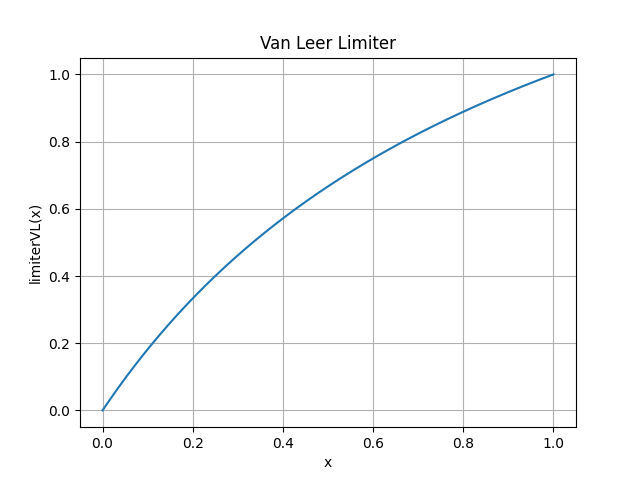

In [25]:
def limiterVL(x):
    # if x <= 0.0:
        # return 0.0
    # x = wp.min(x, scalar_t(1.0e6))
    # vL = 2.0 / (1.0 + x)
    # return x * vL*vL

    return (x + torch.abs(x)) / (1.0 + torch.abs(x))

xx = torch.linspace(0, 1, 1000)
yy = limiterVL(xx)

fig, ax = plt.subplots()
ax.plot(xx.cpu(), yy.cpu())
ax.set_title("Van Leer Limiter")
ax.set_xlabel("x")
ax.set_ylabel("limiterVL(x)")
plt.grid()


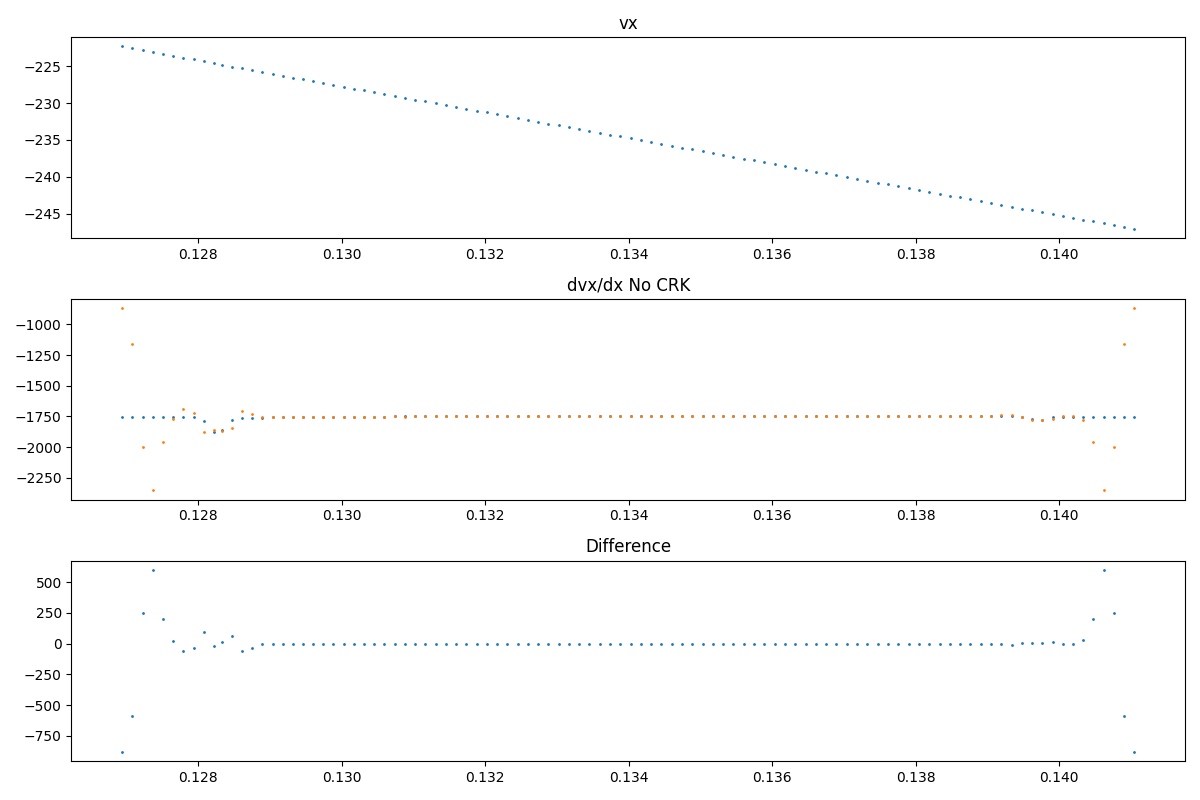

In [26]:
fig, axis = plt.subplots(3,1, figsize = (12, 8), squeeze = False)
plotToAxis1D(axis[0,0], currentState.positions, currentState.velocities[:,0], title = 'vx')

plotToAxis1D(axis[1,0], currentState.positions, velocityGradient[:,0,0], title = 'dvx/dx')
plotToAxis1D(axis[1,0], currentState.positions, velocityGradientNoCRK[:,0,0], title = 'dvx/dx No CRK')
# plotToAxis1D(axis[0,

plotToAxis1D(axis[2,0], currentState.positions, velocityGradient[:,0,0] - velocityGradientNoCRK[:,0,0], title = 'Difference')

fig.tight_layout()

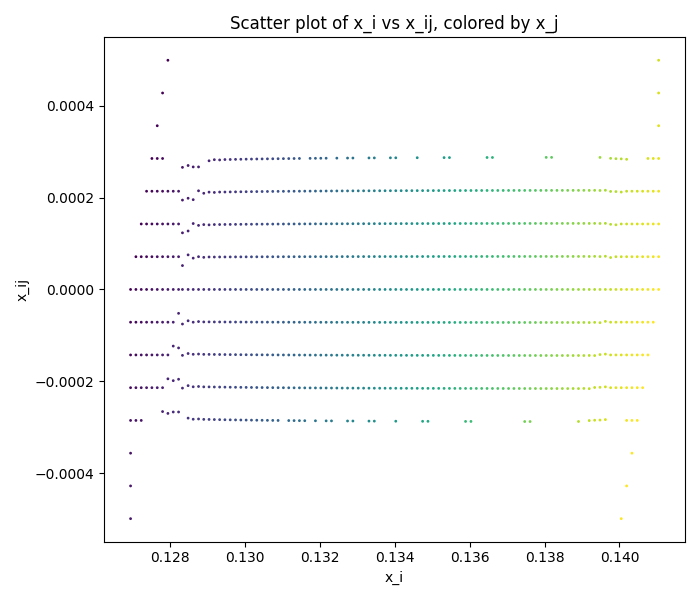

In [27]:

@torch.jit.script
def mod(x, min : float, max : float):
    h = max - min
    return ((x + h / 2.0) - torch.floor((x + h / 2.0) / h) * h) - h / 2.0

def moduloDistance(xij, periodicity, min, max):
    return torch.stack([xij[:,i] if not periodic else mod(xij[:,i], min[i], max[i]) for i, periodic in enumerate(periodicity)], dim = -1)

def mod_distance(xi, xj, 
                 periodicity : Union[bool, torch.Tensor], 
                 minExtent : torch.Tensor, maxExtent : torch.Tensor):
    xij = xi - xj
    periodic = periodicity if isinstance(periodicity, torch.Tensor) else torch.tensor([periodicity for _ in range(xij.shape[1])]).to(xij.device)
    return moduloDistance(xij, periodic, minExtent, maxExtent)

x_i = currentState.positions[adjacency.i]
x_j = currentState.positions[adjacency.j]


# x_ij = x_i - x_j

x_ij = mod_distance(x_i, x_j, config.domain.periodic, config.domain.min, config.domain.max) / 2


fig, axis = plt.subplots(1,1, figsize = (7, 6), squeeze = False)

axis[0,0].scatter(x_i.cpu(), x_ij.cpu(), s = 1, c = x_j.cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('x_ij')
axis[0,0].set_title('Scatter plot of x_i vs x_ij, colored by x_j')
# plt.show()
fig.tight_layout()

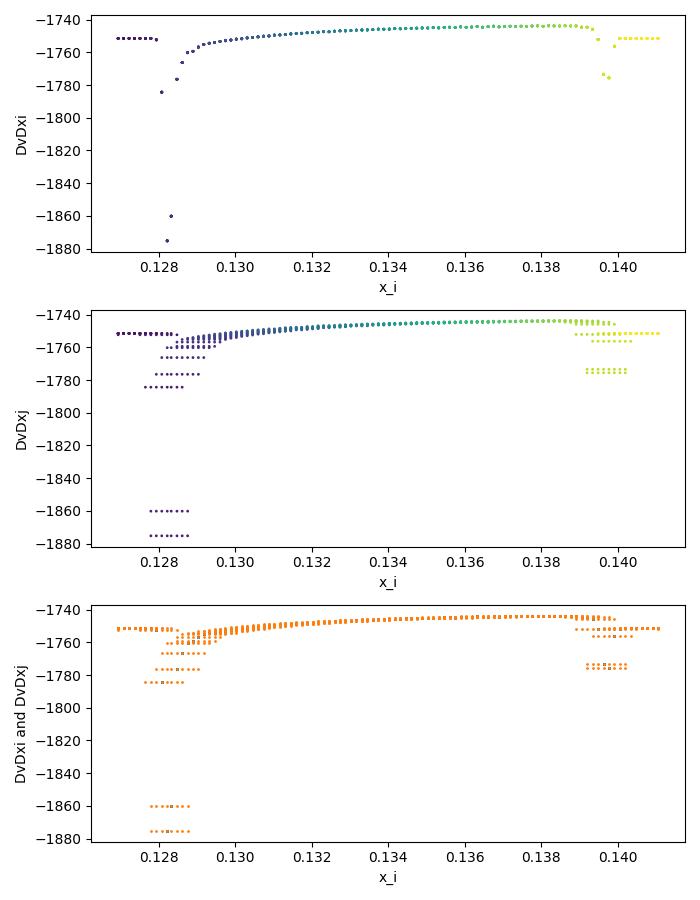

In [28]:
DvDxi = velocityGradient[adjacency.i]
DvDxj = velocityGradient[adjacency.j]

fig, axis = plt.subplots(3,1, figsize = (7, 9), squeeze = False)

axis[0,0].scatter(x_i.cpu(), DvDxi[:,0].cpu(), s = 1, c = x_j.cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('DvDxi')
# axis[0,0].set_title('Scatter plot of x_i vs DvDxi, colored by x_j')

axis[1,0].scatter(x_i.cpu(), DvDxj[:,0].cpu(), s = 1, c = x_j.cpu())
axis[1,0].set_xlabel('x_i')
axis[1,0].set_ylabel('DvDxj')

axis[2,0].scatter(x_i.cpu(), DvDxi.cpu(), s = 1)
axis[2,0].scatter(x_i.cpu(), DvDxj.cpu(), s = 1)
axis[2,0].set_xlabel('x_i')
axis[2,0].set_ylabel('DvDxi and DvDxj')

fig.tight_layout()

In [29]:
gradi = torch.einsum('na, na -> n', torch.einsum('nab, nb -> na', DvDxi, x_ij), x_ij)
gradj = torch.einsum('na, na -> n', torch.einsum('nab, nb -> na', DvDxj, x_ij), x_ij)

print(f'gradj: min: {gradj[~torch.isnan(gradj)].min().item()}, max: {gradj[~torch.isnan(gradj)].max().item()}, mean: {gradj.nanmean().item()}, nans: {torch.isnan(gradj).sum().item()}/{gradj.numel()}, inf values: {(torch.isinf(gradj).sum().item())}')
print(f'gradi: min: {gradi[~torch.isnan(gradi)].min().item()}, max: {gradi[~torch.isnan(gradi)].max().item()}, mean: {gradi.nanmean().item()}, nans: {torch.isnan(gradi).sum().item()}/{gradi.numel()}, inf values: {(torch.isinf(gradi).sum().item())}')

gradi += 1.0e-30
gradj += 1.0e-30

def sgn(x):
    return torch.where(x >= 0, torch.tensor(1.0, device = x.device), torch.tensor(-1.0, device = x.device))

ri = gradi / (sgn(gradj) * torch.abs(gradj).clamp_min_(1.0e-30))
rj = gradj / (sgn(gradi) * torch.abs(gradi).clamp_min_(1.0e-30))

rij = torch.min(ri, rj)

print(f'rij: min: {rij[~torch.isnan(rij)].min().item()}, max: {rij[~torch.isnan(rij)].max().item()}, mean: {rij.nanmean().item()}, nans: {torch.isnan(rij).sum().item()}/{rij.numel()}, inf values: {(torch.isinf(rij).sum().item())}')

gradj: min: -0.00043571803025684356, max: -0.0, mean: -5.3048959472404045e-05, nans: 0/802, inf values: 0
gradi: min: -0.00043571803025694054, max: -0.0, mean: -5.304895947240404e-05, nans: 0/802, inf values: 0
rij: min: 0.9339652276179603, max: 1.0, mean: 0.9972747849025154, nans: 0/802, inf values: 0


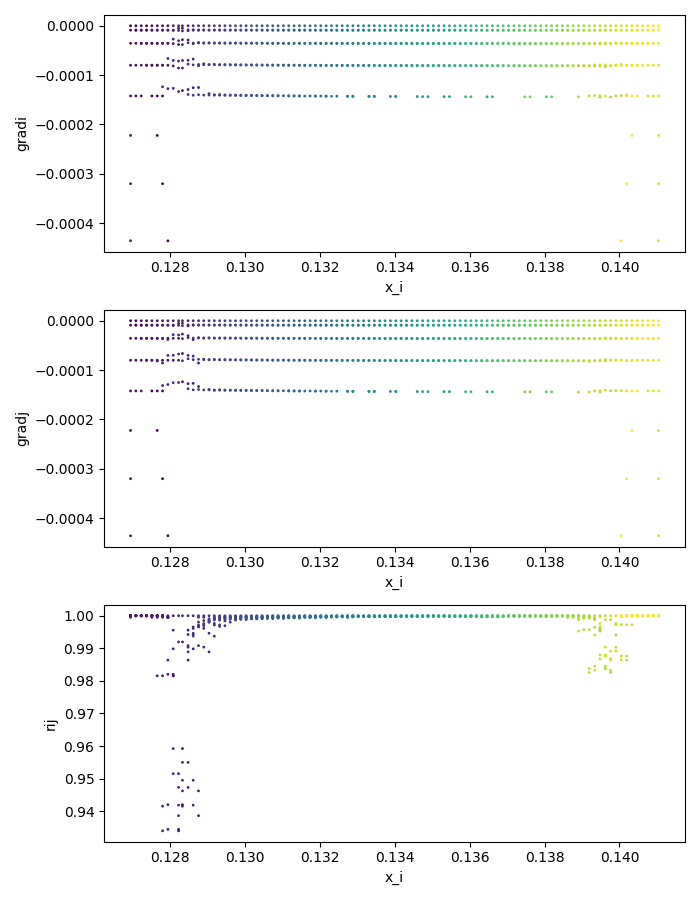

In [30]:
fig, axis = plt.subplots(3,1, figsize = (7, 9), squeeze = False)

axis[0,0].scatter(x_i.cpu(), gradi.cpu(), s = 1, c = x_j.cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('gradi')

axis[1,0].scatter(x_i.cpu(), gradj.cpu(), s = 1, c = x_j.cpu())
axis[1,0].set_xlabel('x_i')
axis[1,0].set_ylabel('gradj')

axis[2,0].scatter(x_i.cpu(), rij.cpu(), s = 1, c = x_j.cpu())
axis[2,0].set_xlabel('x_i')
axis[2,0].set_ylabel('rij')

fig.tight_layout()


In [31]:
phi_ij = limiterVL(rij)

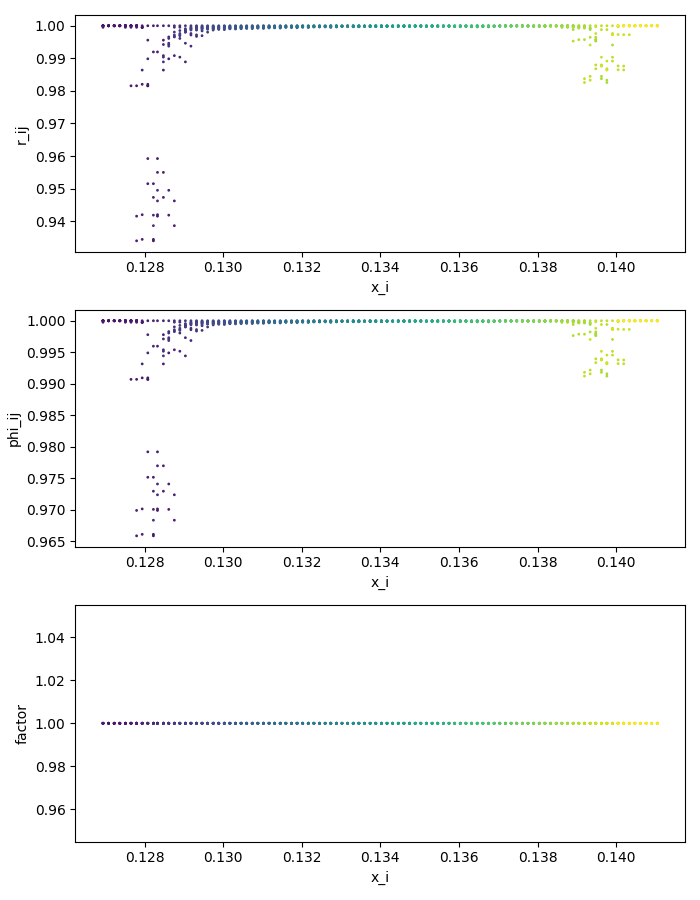

In [32]:
hi = currentState.supports[adjacency.i]
hj = currentState.supports[adjacency.j]

eta_i = x_ij/hi#*ks #* eta_max
eta_j = x_ij/hj#*ks #* eta_max

eta_i_norm = torch.sqrt(torch.einsum('na, na -> n', eta_i, eta_i))
eta_j_norm = torch.sqrt(torch.einsum('na, na -> n', eta_j, eta_j))
eta_ij = torch.min(eta_i_norm, eta_j_norm)

eta_crit = 0.25
eta_fold = 0.2

factor = (1.0)
# if eta_ij < eta_crit:
factor = torch.where(eta_ij < eta_crit, torch.exp(- ((eta_ij - eta_crit)/eta_fold)**(2.0)), factor)

fig, axis = plt.subplots(3,1, figsize = (7, 9), squeeze = False)

axis[0,0].scatter(x_i.cpu(), rij.cpu(), s = 1, c = x_j.cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('r_ij')

axis[1,0].scatter(x_i.cpu(), phi_ij.cpu(), s = 1, c = x_j.cpu())
axis[1,0].set_xlabel('x_i')
axis[1,0].set_ylabel('phi_ij')

axis[2,0].scatter(x_i.cpu()[adjacency.i.cpu() != adjacency.j.cpu()], factor.cpu()[adjacency.i.cpu() != adjacency.j.cpu()], s = 1, c = x_j[adjacency.i.cpu() != adjacency.j.cpu()].cpu())
axis[2,0].set_xlabel('x_i')
axis[2,0].set_ylabel('factor')

fig.tight_layout()



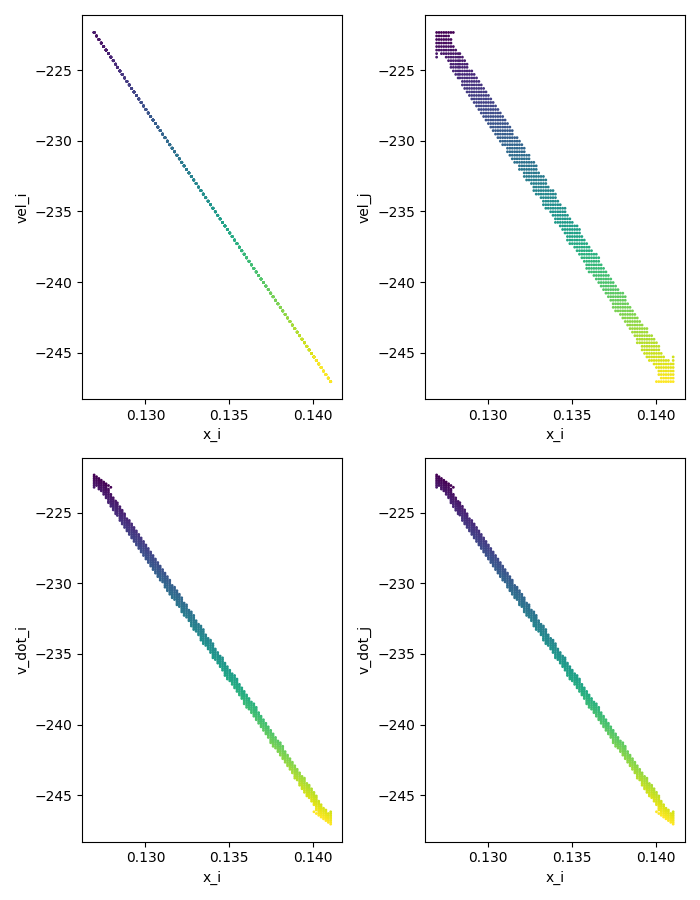

In [33]:
vel_i = currentState.velocities[adjacency.i]
vel_j = currentState.velocities[adjacency.j]

v_corr_i = 2 / (2.0) * torch.einsum('nij, nj -> ni', velocityGradient[adjacency.i], x_ij)
v_corr_j = 2 / (2.0) * torch.einsum('nij, nj -> ni', velocityGradient[adjacency.j], x_ij)

v_dot_i = vel_i - v_corr_i
v_dot_j = vel_j + v_corr_j

fig, axis = plt.subplots(2,2, figsize = (7, 9), squeeze = False)

axis[0,0].scatter(x_i.cpu(), vel_i[:,0].cpu(), s = 1, c = x_j.cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('vel_i')

axis[0,1].scatter(x_i.cpu(), vel_j[:,0].cpu(), s = 1, c = x_j.cpu())
axis[0,1].set_xlabel('x_i')
axis[0,1].set_ylabel('vel_j')

axis[1,0].scatter(x_i.cpu(), v_dot_i[:,0].cpu(), s = 1, c = x_j.cpu())
axis[1,0].set_xlabel('x_i')
axis[1,0].set_ylabel('v_dot_i')

axis[1,1].scatter(x_i.cpu(), v_dot_j[:,0].cpu(), s = 1, c = x_j.cpu())
axis[1,1].set_xlabel('x_i')
axis[1,1].set_ylabel('v_dot_j')

fig.tight_layout()


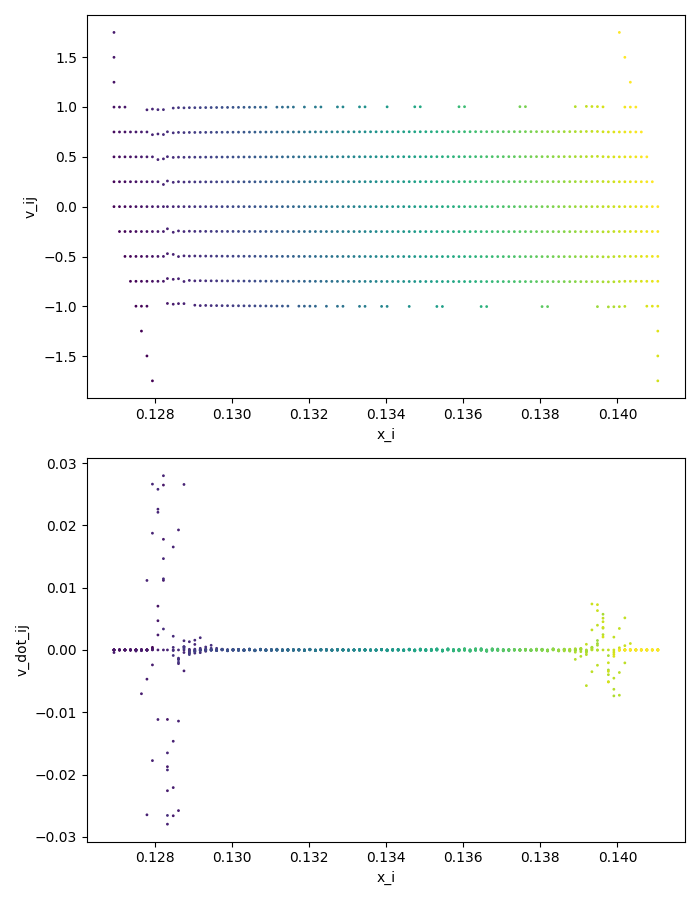

In [34]:

v_ij = vel_i - vel_j
v_dot_ij = v_dot_i - v_dot_j

fig, axis = plt.subplots(2,1, figsize = (7, 9), squeeze = False)
axis[0,0].scatter(x_i.cpu(), v_ij[:,0].cpu(), s = 1, c = x_j.cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('v_ij')

axis[1,0].scatter(x_i.cpu(), v_dot_ij[:,0].cpu(), s = 1, c = x_j.cpu())
axis[1,0].set_xlabel('x_i')
axis[1,0].set_ylabel('v_dot_ij')

fig.tight_layout()

In [ ]:
import time
import torch

class TimedBlock:
    def __init__(self, name: str = "Timed block", use_cuda: bool = True, device=None):
        self.name = name
        self.device = device
        self.use_cuda = use_cuda and torch.cuda.is_available()

        self.cpu_ms = None
        self.cuda_ms = None

        self._cpu_start = None
        self._start_event = None
        self._end_event = None

    def __enter__(self):
        self._cpu_start = time.perf_counter()

        if self.use_cuda:
            if self.device is not None:
                torch.cuda.synchronize(self.device)
            else:
                torch.cuda.synchronize()

            self._start_event = torch.cuda.Event(enable_timing=True)
            self._end_event = torch.cuda.Event(enable_timing=True)
            self._start_event.record()

        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.cpu_ms = (time.perf_counter() - self._cpu_start) * 1000.0

        if self.use_cuda:
            self._end_event.record()
            self._end_event.synchronize()
            self.cuda_ms = self._start_event.elapsed_time(self._end_event)
            print(f"[{self.name}] CPU: {self.cpu_ms:.3f} ms | CUDA: {self.cuda_ms:.3f} ms")
        else:
            print(f"[{self.name}] CPU: {self.cpu_ms:.3f} ms | CUDA: N/A")

        return False

In [ ]:
with TimedBlock("compSPH step", use_cuda=True, device=device):
    compSPH_step(
        runningState,
        config.dt,
        config,
        schemeConfig,
    )

[compSPH step] CPU: 457.498 ms | CUDA: 432.784 ms


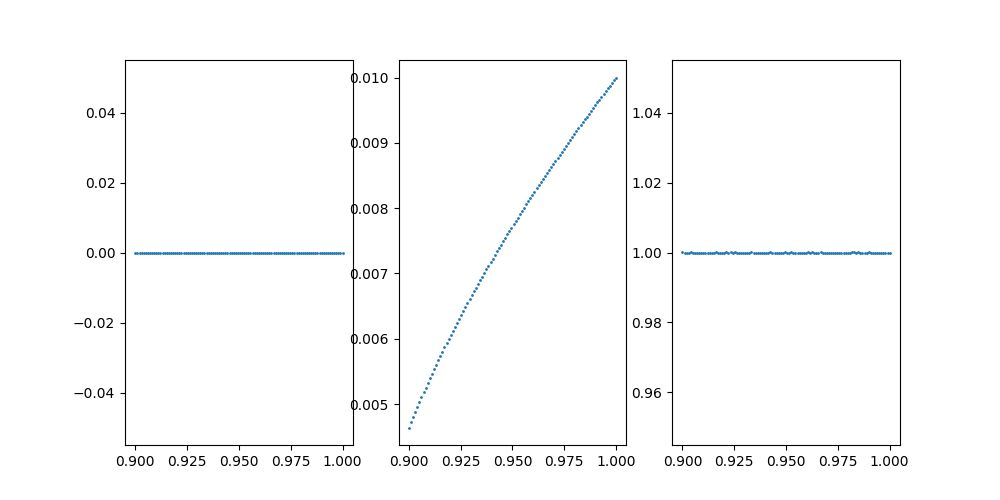

In [ ]:
fig, axis = plt.subplots(1, 3, figsize = (10, 5), squeeze=False)
# setupPlot(fig, axis, 0)

vel_error = kidderSolution.vr(runningState.t.cpu().numpy() if isinstance(runningState.t, torch.Tensor) else runningState.t, runningState.state.positions.cpu().numpy()[:,0]) - runningState.state.velocities.cpu().numpy()[:,0]
axis[0,0].scatter(runningState.state.positions.cpu().numpy(), vel_error, s = 1)

# axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = 1)
# axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.supports.cpu().numpy(), s = 1)

entropy = runningState.state.entropies
axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = 1)

entropySolution = kidderSolution.P(0, runningState.state.positions.cpu().numpy()) / kidderSolution.rho(0, runningState.state.positions.cpu().numpy())**schemeConfig.gamma
# axis[0,1].scatter(runningState.state.positions.cpu().numpy(), entropySolution, s = 1)

axis[0,2].scatter(runningState.state.positions.cpu().numpy(), entropy.cpu().numpy() / entropySolution.flatten(), s = 1)

In [ ]:
currentState = runningState.state.initializeNewState()

In [ ]:

from warp import Kernel

from compressibleSPH.config import SimulationConfig
from compressibleSPH.utils import *
from sphWarpCore import *
import torch
from compressibleSPH.system import *
from compressibleSPH.modules import idealGasEOS, evaluateOptimalSupport
# from optimalSupport import evaluateOptimalSupport

# from sphWarpCore.kernels.wp_kernel import sphKernel
from diffSPH.kernels import Kernel as diffSPHKernel
from diffSPH.kernels import KernelType

# class KernelFunctions(Enum):
#     Poly6 = 20
#     CubicSpline = 30
#     QuarticSpline = 31
#     QuinticSpline = 32
#     B7 = 33
#     Wendland2 = 0
#     Wendland4 = 1
#     Wendland6 = 2
#     Spiky = 21
#     ViscosityKernel = 30
#     CohesionKernel = 31
#     AdhesionKernel = 32

# class KernelType(Enum):
#     Poly6 = 0
#     CubicSpline = 1
#     QuarticSpline = 2
#     QuinticSpline = 3
#     B7 = 4
#     Wendland2 = 5
#     Wendland4 = 6
#     Wendland6 = 7
#     Spiky = 8
#     ViscosityKernel = 9
#     CohesionKernel = 10
#     AdhesionKernel = 11

def warpKernelToDiffSPHKernel(
        warpKernel: KernelFunctions
):
    if warpKernel == KernelFunctions.Poly6:
        return KernelType.Poly6
    elif warpKernel == KernelFunctions.CubicSpline:
        return KernelType.CubicSpline
    elif warpKernel == KernelFunctions.QuarticSpline:
        return KernelType.QuarticSpline
    elif warpKernel == KernelFunctions.QuinticSpline:
        return KernelType.QuinticSpline
    elif warpKernel == KernelFunctions.B7:
        return KernelType.B7
    elif warpKernel == KernelFunctions.Wendland2:
        return KernelType.Wendland2
    elif warpKernel == KernelFunctions.Wendland4:
        return KernelType.Wendland4
    elif warpKernel == KernelFunctions.Wendland6:
        return KernelType.Wendland6
    elif warpKernel == KernelFunctions.Spiky:
        return KernelType.Spiky
    elif warpKernel == KernelFunctions.ViscosityKernel:
        return KernelType.ViscosityKernel
    elif warpKernel == KernelFunctions.CohesionKernel:
        return KernelType.CohesionKernel
    elif warpKernel == KernelFunctions.AdhesionKernel:
        return KernelType.AdhesionKernel
    else:
        raise ValueError(f'Unknown kernel type {warpKernel}')


In [ ]:
rho_optimal, h_optimal, adjacency, *_ = evaluateOptimalSupport(currentState, config, schemeConfig, SupportScheme.Gather, None)
currentState.supports = h_optimal
currentState.densities = rho_optimal

verletScale = config.verletScale

adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = adjacency,
    verbose = False)

currentState.densities = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
    ),
    domain = config.domain,
    adjacency = adjacency,
)

Module compressibleSPH.modules.adaptiveSupport.wp_psi 4cacf24 load on device 'cuda:0' took 1.11 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_psi0 f9bb264 load on device 'cuda:0' took 2.52 ms  (cached)
Module sphWarpCore.operations.wp_density 813da29 load on device 'cuda:0' took 2.59 ms  (cached)


In [ ]:
from compressibleSPH.modules.compSPH.accel import computeCompSPHAccelWarp

scheme = SupportScheme.KernelMeanSymmetric

dvdt, pressureAccel_ij, viscosityAccel_ij = computeCompSPHAccelWarp(
    queryParticles = currentState,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = scheme
    ),
    domain = config.domain,
    conductivityParams= schemeConfig.diffusionParams,

    queryEnergies = currentState.internalEnergies,
    queryVelocities= currentState.velocities,
    queryCs = currentState.soundspeeds,
    queryAlphas = currentState.alphas,
    queryPressures = currentState.pressures,

    adjacency = adjacency,
    gradHState = None
)

Module compressibleSPH.modules.compSPH.accel 5a356bc load on device 'cuda:0' took 8.28 ms  (cached)


In [ ]:
from diffSPH.schemes.states.compressiblesph import CompressibleState as CompState
from diffSPH.kernels import getSPHKernelv2
from diffSPH.neighborhood import evaluateNeighborhood
from diffSPH.modules.density import computeDensity

from diffSPH.modules.compSPH import compSPH_acceleration, compSPH_dudt, compute_fij

from diffSPH.enums import SupportScheme as SupportSchemeDiffSPH

diffSPHDiffusionConfig = {    
    'diffusion':{
        'C_l': 1,
        'C_q': 1,
        'Cu_l': 1,
        'Cu_q': 1,
        'monaghanSwitch': True,
        'viscosityTerm': 'Monaghan',
        'correctXi': True,
        
        'viscosityFormulation': 'Monaghan1992',
        'thermalConductivityFormulation': 'Price2008',
        'signalTerm': 'Price2019',
        'use_cbar': False,
        'use_rho_bar': False,
        'use_h_bar': False,
        'scaleBeta': False,
        'K': 1.0,
        
        'thermalConductivity' : 0.0,
    },
    'diffusionSwitch':{
        'scheme': ViscositySwitch.NoneSwitch,
        'limitXi': False,
    },
    'domain': config.domain,
    'kernel': KernelType.B7,
    'verbose': True,
    'gamma': schemeConfig.gamma,
    'fluid':{
        'gamma': schemeConfig.gamma,
    }
}

diffSPHState = CompState(
    positions = currentState.positions,
    velocities = currentState.velocities,
    densities = currentState.densities,
    supports = currentState.supports,
    internalEnergies = currentState.internalEnergies,
    totalEnergies = currentState.totalEnergies,
    entropies = currentState.entropies,
    soundspeeds= currentState.soundspeeds,
    masses = currentState.masses,
    kinds = currentState.kinds,
    materials = currentState.materials,
    UIDs = currentState.UIDs,
    pressures = currentState.pressures,
    omega = torch.ones_like(currentState.densities),
    alphas = currentState.alphas,
    alpha0s = currentState.alpha0s,
)

wrappedKernel = getSPHKernelv2(KernelType.B7)
verletScale = 1
neighborhood, neighbors = evaluateNeighborhood(diffSPHState, config.domain, KernelType.B7, verletScale = 1.0, mode = SupportSchemeDiffSPH.SuperSymmetric, priorNeighborhood=None)

diffSPHState.densities = computeDensity(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportSchemeDiffSPH.Gather, config)

dvdt_dsph, ap_ij_dsph, av_ij_dsph = compSPH_acceleration(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportSchemeDiffSPH.SuperSymmetric, diffSPHDiffusionConfig)

print(f'Max pressure acceleration: {ap_ij_dsph.abs().max()} [shape: {ap_ij_dsph.shape}]')
print(f'Max viscosity acceleration: {av_ij_dsph.abs().max()} [shape: {av_ij_dsph.shape}]')
print(f'Max total acceleration: {(dvdt_dsph).abs().max()} [shape: {dvdt_dsph.shape}]')

dudt_dsph = compSPH_dudt(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportSchemeDiffSPH.SuperSymmetric, diffSPHDiffusionConfig)

print(f'Max du/dt: {dudt_dsph.abs().max()}')


Max pressure acceleration: 83728.40724334466 [shape: torch.Size([698, 1])]
Max viscosity acceleration: 0.0 [shape: torch.Size([698, 1])]
Max total acceleration: 115372.10716922725 [shape: torch.Size([100, 1])]
Max du/dt: 0.0


In [ ]:
from diffSPH.neighborhood import coo_to_csr
csr_neighrs = coo_to_csr(neighbors.get('noghost')[0])
print(csr_neighrs)

SparseCSR(indices=tensor([ 0,  1,  2,  3,  4,  5,  0,  1,  2,  3,  4,  5,  0,  1,  2,  3,  4,  5,
         0,  1,  2,  3,  4,  5,  6,  0,  1,  2,  3,  4,  5,  6,  7,  0,  1,  2,
         3,  4,  5,  6,  7,  8,  3,  4,  5,  6,  7,  8,  9,  4,  5,  6,  7,  8,
         9, 10,  5,  6,  7,  8,  9, 10, 11,  6,  7,  8,  9, 10, 11, 12,  7,  8,
         9, 10, 11, 12, 13,  8,  9, 10, 11, 12, 13, 14,  9, 10, 11, 12, 13, 14,
        15, 10, 11, 12, 13, 14, 15, 16, 11, 12, 13, 14, 15, 16, 17, 12, 13, 14,
        15, 16, 17, 18, 13, 14, 15, 16, 17, 18, 19, 14, 15, 16, 17, 18, 19, 20,
        15, 16, 17, 18, 19, 20, 21, 16, 17, 18, 19, 20, 21, 22, 17, 18, 19, 20,
        21, 22, 23, 18, 19, 20, 21, 22, 23, 24, 19, 20, 21, 22, 23, 24, 25, 20,
        21, 22, 23, 24, 25, 26, 21, 22, 23, 24, 25, 26, 27, 22, 23, 24, 25, 26,
        27, 28, 23, 24, 25, 26, 27, 28, 29, 24, 25, 26, 27, 28, 29, 30, 25, 26,
        27, 28, 29, 30, 31, 26, 27, 28, 29, 30, 31, 32, 27, 28, 29, 30, 31, 32,
        33, 28, 29, 30

In [ ]:
adjacency.i = neighbors.neighbors.row
adjacency.j = neighbors.neighbors.col

Max density difference between current state and diffSPH state: 3.434752482434078e-16


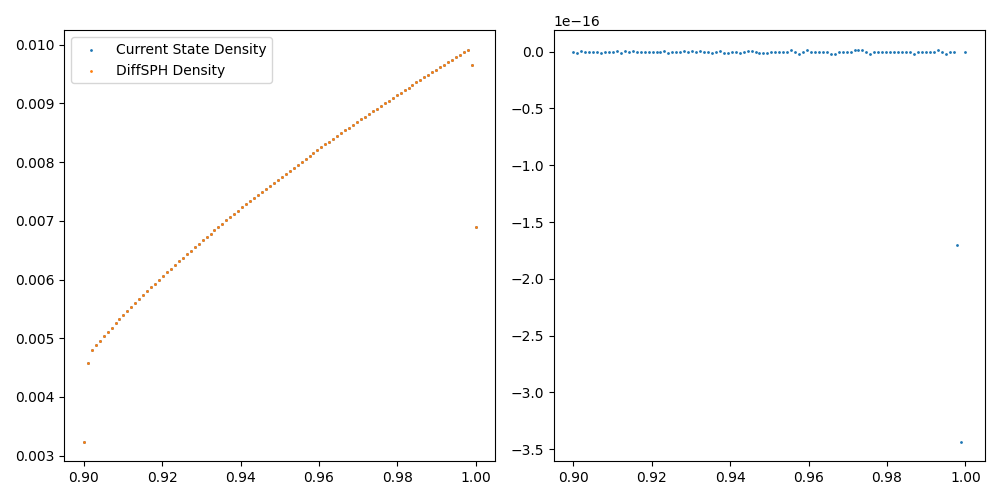

In [ ]:

currentState.densities = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
    ),
    domain = config.domain,
    adjacency = adjacency,
)

diffSPHState.densities = computeDensity(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportSchemeDiffSPH.Gather, config)

density_diff = currentState.densities - diffSPHState.densities
print(f'Max density difference between current state and diffSPH state: {density_diff.abs().max()}')
fig, axis = plt.subplots(1, 2, figsize = (10, 5), squeeze=False)

band_left = currentState.positions.cpu().numpy()[band,0]
band_right = currentState.positions.cpu().numpy()[-band,0]

band_left = 0.0
band_right = 1.0

band_mask = ((currentState.positions.cpu().numpy() >= band_left) & (currentState.positions.cpu().numpy() <= band_right))[:,0]

axis[0,0].scatter(currentState.positions[band_mask,0].cpu().numpy(), currentState.densities[band_mask].cpu().numpy(), s = 1, label = 'Current State Density')
axis[0,0].scatter(diffSPHState.positions[band_mask,0].cpu().numpy(), diffSPHState.densities[band_mask].cpu().numpy(), s = 1, label = 'DiffSPH Density')
axis[0,0].legend()

axis[0,1].scatter(currentState.positions[band_mask,0].cpu().numpy(), density_diff[band_mask].cpu().numpy(), s = 1, label = 'Current State Pressure')

fig.tight_layout()

In [ ]:
currentState.positions[:,0]

tensor([0.9000, 0.9010, 0.9020, 0.9030, 0.9040, 0.9051, 0.9061, 0.9071, 0.9081,
        0.9091, 0.9101, 0.9111, 0.9121, 0.9131, 0.9141, 0.9152, 0.9162, 0.9172,
        0.9182, 0.9192, 0.9202, 0.9212, 0.9222, 0.9232, 0.9242, 0.9253, 0.9263,
        0.9273, 0.9283, 0.9293, 0.9303, 0.9313, 0.9323, 0.9333, 0.9343, 0.9354,
        0.9364, 0.9374, 0.9384, 0.9394, 0.9404, 0.9414, 0.9424, 0.9434, 0.9444,
        0.9455, 0.9465, 0.9475, 0.9485, 0.9495, 0.9505, 0.9515, 0.9525, 0.9535,
        0.9545, 0.9556, 0.9566, 0.9576, 0.9586, 0.9596, 0.9606, 0.9616, 0.9626,
        0.9636, 0.9646, 0.9657, 0.9667, 0.9677, 0.9687, 0.9697, 0.9707, 0.9717,
        0.9727, 0.9737, 0.9747, 0.9758, 0.9768, 0.9778, 0.9788, 0.9798, 0.9808,
        0.9818, 0.9828, 0.9838, 0.9848, 0.9859, 0.9869, 0.9879, 0.9889, 0.9899,
        0.9909, 0.9919, 0.9929, 0.9939, 0.9949, 0.9960, 0.9970, 0.9980, 0.9990,
        1.0000], device='cuda:0', dtype=torch.float64)

In [ ]:

print(f'Max pressure acceleration: {pressureAccel_ij.abs().max()} [shape: {pressureAccel_ij.shape}]')
print(f'Max viscosity acceleration: {viscosityAccel_ij.abs().max()} [shape: {viscosityAccel_ij.shape}]')
print(f'Max total acceleration: {(dvdt).abs().max()} [shape: {dvdt.shape}]')

Max pressure acceleration: 83728.40724334598 [shape: torch.Size([698, 1])]
Max viscosity acceleration: 0.0 [shape: torch.Size([698, 1])]
Max total acceleration: 115372.1071692296 [shape: torch.Size([100, 1])]


In [ ]:
ap_ij_error = pressureAccel_ij - ap_ij_dsph
av_ij_error = viscosityAccel_ij - av_ij_dsph
dvdt_error = dvdt - dvdt_dsph

print(f'Max pressure acceleration error: {ap_ij_error.abs().max()}')
print(f'Max viscosity acceleration error: {av_ij_error.abs().max()}')
print(f'Max total acceleration error: {(dvdt_error).abs().max()}')

Max pressure acceleration error: 1.1652446119114757e-08
Max viscosity acceleration error: 0.0
Max total acceleration error: 9.411451173946261e-09


Text(0.5, 1.0, 'Pressure Acceleration Error')

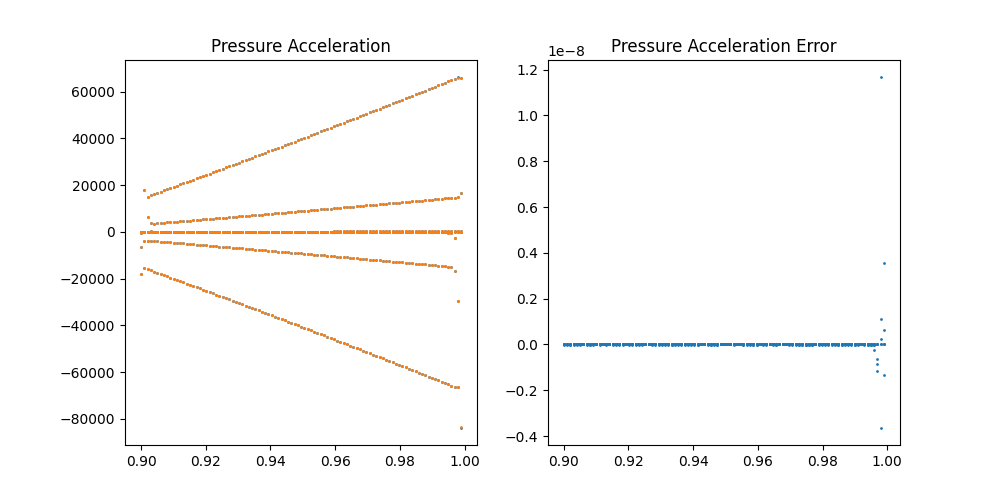

In [ ]:
fig, axis = plt.subplots(1, 2, figsize = (10, 5), squeeze=False)

xi = currentState.positions.cpu().numpy()[adjacency.i.cpu()]
band_left = currentState.positions.cpu().numpy()[band]
band_right = currentState.positions.cpu().numpy()[-band]

band_left = 0.0
band_right = 1.0

xi_band = xi[(xi > band_left) & (xi < band_right)]
ap_ij_band = pressureAccel_ij[(xi > band_left) & (xi < band_right)]
ap_ij_dsph_band = ap_ij_dsph[(xi > band_left) & (xi < band_right)]

axis[0,0].scatter(xi_band, ap_ij_band.cpu().numpy(), s = 1, label = 'CompSPHAccel')
axis[0,0].scatter(xi_band, ap_ij_dsph_band.cpu().numpy(), s = 1, label = 'diffSPH Accel')
axis[0,0].set_title('Pressure Acceleration')

diff = ap_ij_band - ap_ij_dsph_band
axis[0,1].scatter(xi_band, diff.cpu().numpy(), s = 1)
axis[0,1].set_title('Pressure Acceleration Error')

xi: 3.9327351446625003, cd: 2.158131, h: 0.003999999999999999


Text(0.5, 1.0, 'Viscosity Acceleration Error')

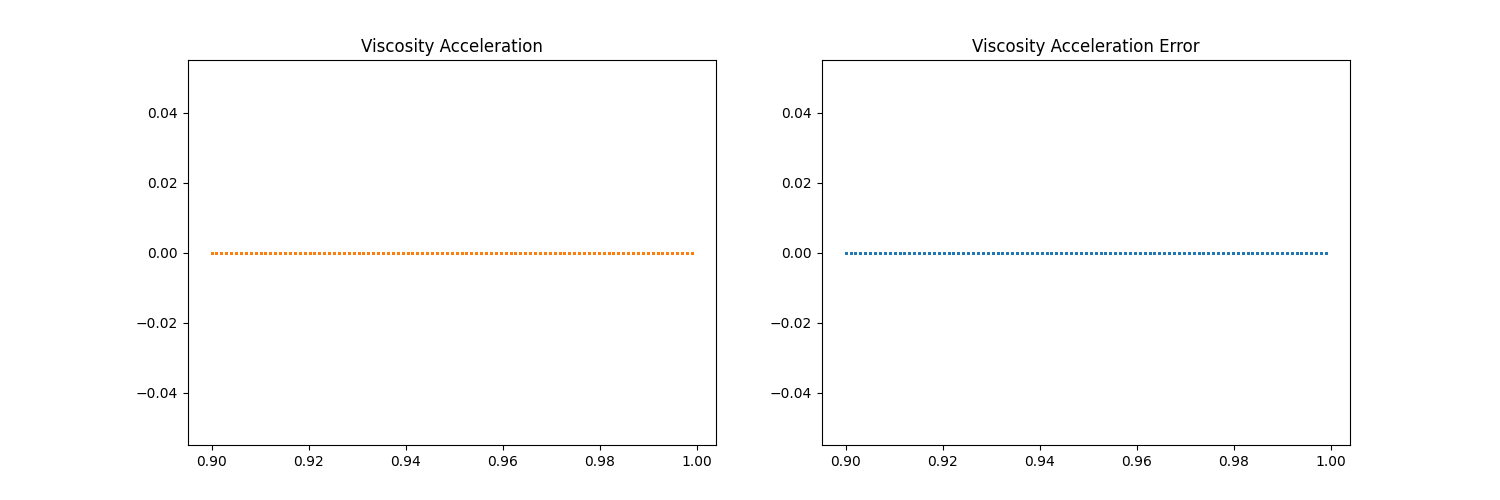

In [ ]:
fig, axis = plt.subplots(1, 2, figsize = (15, 5), squeeze=False)


xi = currentState.positions.cpu().numpy()[adjacency.i.cpu()]
band_left = currentState.positions.cpu().numpy()[band]
band_right = currentState.positions.cpu().numpy()[-band]
band_left = 0.0
band_right = 1.0


from sphWarpCore.kernels.wp_kernel import *
kernel_xi = sphKernel_xi(config.kernel.value, 2)
kernel_cd = sphKernelScale(config.kernel.value, 2)
print(f'xi: {kernel_xi}, cd: {kernel_cd}, h: {simulationState.supports[0].item()}')
ratio = float(kernel_xi / kernel_cd)

xi_band = xi[(xi > band_left) & (xi < band_right)]
av_ij_band = viscosityAccel_ij[(xi > band_left) & (xi < band_right)]
av_ij_dsph_band = av_ij_dsph[(xi > band_left) & (xi < band_right)]# * ratio

axis[0,0].scatter(xi_band, av_ij_band.cpu().numpy(), s = 1, label = 'CompSPHAccel')
axis[0,0].scatter(xi_band, av_ij_dsph_band.cpu().numpy(), s = 1, label = 'diffSPH Accel')
axis[0,0].set_title('Viscosity Acceleration')

diff = av_ij_band - av_ij_dsph_band
axis[0,1].scatter(xi_band, diff.cpu().numpy(), s = 1)
axis[0,1].set_title('Viscosity Acceleration Error')

In [ ]:

v_halfstep = diffSPHState.velocities + 0.5 * config.dt * dvdt

f_ij = computeCompSPHBalanceTermWarp(
    queryParticles = currentState,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = config.supportMode
    ),
    domain = config.domain,

    queryEnergies = currentState.internalEnergies,
    queryVelocities= v_halfstep,
    queryPressures = currentState.pressures,

    pairWise_pressureAccel= pressureAccel_ij,
    pairWise_viscosityAccel = viscosityAccel_ij,
    energyScheme = EnergyScheme.CRK,
    dt=config.dt,
    gamma = schemeConfig.gamma,

    adjacency = adjacency,
    gradHState = None
)
print(f'Max f_ij: {f_ij.abs().max()}, Mean: {f_ij.mean()}, Min: {f_ij.min()}, Max: {f_ij.max()}')
print(f'Max deviation from 0.5: {(f_ij - 0.5).abs().max()}')



Module compressibleSPH.modules.compSPH.balance faff88a load on device 'cuda:0' took 8.92 ms  (cached)
Max f_ij: 0.7532068004592549, Mean: 0.5, Min: 0.24679319954074508, Max: 0.7532068004592549
Max deviation from 0.5: 0.2532068004592549


In [ ]:
from diffSPH.enums import EnergyScheme as EnergySchemeDiffSPH
diffSPHDiffusionConfig['energyScheme'] = EnergySchemeDiffSPH.CRK

f_ij_dsph = compute_fij(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig, config.dt, v_halfstep, pressureAccel_ij, viscosityAccel_ij)

print(f'Max f_ij (diffSPH): {f_ij_dsph.abs().max()}, Mean: {f_ij_dsph.mean()}, Min: {f_ij_dsph.min()}, Max: {f_ij_dsph.max()}')
print(f'Max deviation from 0.5 (diffSPH): {(f_ij_dsph - 0.5).abs().max()}')



Max f_ij (diffSPH): 0.800208137451089, Mean: 0.5, Min: 0.199791862548911, Max: 0.800208137451089
Max deviation from 0.5 (diffSPH): 0.300208137451089


Text(0.5, 1.0, 'Balance Error')

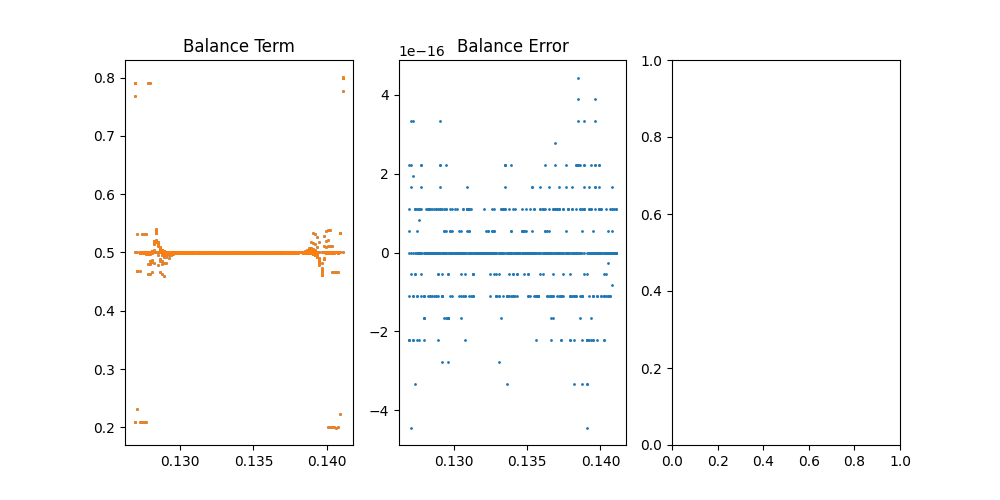

In [ ]:
fig, axis = plt.subplots(1, 3, figsize = (10, 5), squeeze=False)

xi = currentState.positions.cpu().numpy()[adjacency.i.cpu()]
band_left = currentState.positions.cpu().numpy()[band]
band_right = currentState.positions.cpu().numpy()[-band]
band_left = 0.0
band_right = 1.0


xi_band = xi[(xi > band_left) & (xi < band_right)]
f_ij_band = f_ij[((xi > band_left) & (xi < band_right))[:, 0]]
f_ij_dsph_band = f_ij_dsph[((xi > band_left) & (xi < band_right))[:, 0]]

axis[0,0].scatter(xi_band, f_ij_band.cpu().numpy(), s = 1, label = 'CompSPHAccel')
axis[0,0].scatter(xi_band, f_ij_dsph_band.cpu().numpy(), s = 1, label = 'diffSPH Accel')
axis[0,0].set_title('Balance Term')

diff = f_ij_band - f_ij_dsph_band
axis[0,1].scatter(xi_band, diff.cpu().numpy(), s = 1)
axis[0,1].set_title('Balance Error')

In [ ]:

dudt = computeCompSPHdudtWarp(
    queryParticles = currentState,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = SupportScheme.KernelMeanSymmetric #E.3
        ),
    domain = config.domain,
    conductivityParams= schemeConfig.diffusionParams,

    queryEnergies = currentState.internalEnergies,
    queryVelocities= currentState.velocities,
    queryCs = currentState.soundspeeds,
    queryAlphas = currentState.alphas,
    queryPressures = currentState.pressures,

    adjacency = adjacency,
    gradHState = None
)


dudt_diffSPH = compSPH_dudt(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportSchemeDiffSPH.Gather, diffSPHDiffusionConfig)

Text(0.5, 1.0, 'dudt Error')

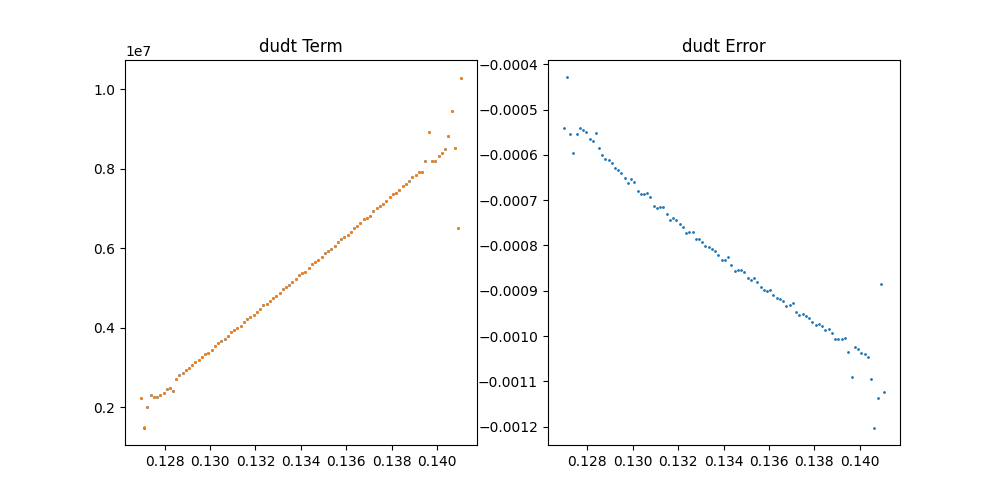

In [ ]:
fig, axis = plt.subplots(1, 2, figsize = (10, 5), squeeze=False)

xi = currentState.positions.cpu().numpy()
band_left = currentState.positions.cpu().numpy()[band]
band_right = currentState.positions.cpu().numpy()[-band]
band_left = 0.0
band_right = 1.0


xi_band = xi[(xi > band_left) & (xi < band_right)]
f_ij_band = dudt[((xi > band_left) & (xi < band_right))[:, 0]]
f_ij_dsph_band = dudt_diffSPH[((xi > band_left) & (xi < band_right))[:, 0]]

axis[0,0].scatter(xi_band, f_ij_band.cpu().numpy(), s = 1, label = 'CompSPHAccel')
axis[0,0].scatter(xi_band, f_ij_dsph_band.cpu().numpy(), s = 1, label = 'diffSPH Accel')
axis[0,0].set_title('dudt Term')

diff = f_ij_band - f_ij_dsph_band
axis[0,1].scatter(xi_band, diff.cpu().numpy(), s = 1)
axis[0,1].set_title('dudt Error')

In [ ]:

rho_optimal, h_optimal, adjacency, *_ = evaluateOptimalSupport(currentState, config, schemeConfig, SupportScheme.Gather, None)
    # currentState.supports = h_optimal
    # currentState.densities = rho_optimal


In [ ]:

from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen

diffSPHDiffusionConfig['support'] = {
    'LUT' : None
}
diffSPHDiffusionConfig['targetNeighbors'] = config.targetNeighbors

rho, h_i_new, rhos, hs, neighborhood = evaluateOptimalSupportOwen(diffSPHState, diffSPHDiffusionConfig['kernel'], neighborhood, SupportScheme.Gather, diffSPHDiffusionConfig)

In [ ]:
h_i_new - h_optimal

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.], device='cuda:0', dtype=torch.float64)

In [ ]:
h_optimal

tensor([0.0010, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,
        0.0010], device='cuda:0', dtype=torch.float64)